# Project V1.5 Final Report

이 노트북은 `Next200 v1.5`의 최종 정리본입니다.

핵심 목적은 세 가지입니다.

1. `v1`에서 무엇을 개선했는지 요약
2. 어떤 모델과 피처 조합이 가장 좋았는지 정리
3. `v1`과 `v1.5_best`를 직접 비교


## Summary

- `v1` 기준 모델: `LightGBM + core 10개 피처`
- `v1.5_best` 기준 모델: `XGBoost + 11개 피처`
- holdout(`2025_H1`, `2025_H2`) 기준 `strong_in/out precision`과 `top200_accuracy` 모두 개선
- 특히 `strong_out_precision` 개선 폭이 가장 큼


In [1]:
from pathlib import Path
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "data").exists() and (BASE_DIR.parent / "data").exists():
    BASE_DIR = BASE_DIR.parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

MODEL_PKG_PATH = BASE_DIR / "data" / "raw" / "model_package_v1_5.pkl"
if not MODEL_PKG_PATH.exists():
    MODEL_PKG_PATH = BASE_DIR / "data" / "raw" / "model_package.pkl"

with MODEL_PKG_PATH.open("rb") as f:
    pkg = pickle.load(f)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)


## 방법론 기반 제외 규칙 업데이트

- `v1.5`는 점수화와 성능 평가 전에 먼저 eligible universe filtering을 적용합니다.
- KOSPI 200 방법론 기준으로 아래 제외 규칙을 반영합니다.
  - 관리 / 경고 지정 종목
  - 리츠
  - 유동비율 10% 미만 종목
  - 상장 6개월 미만 종목
  - 비보통주
  - `088980`(`맥쿼리인프라`) 같은 사회기반시설투융자회사 예외 종목
  - 미래 주간 데이터에서 `스팩` 키워드로 식별되는 종목
- 이 규칙은 학습(`build_v15_model.py`), 주간 예측, Streamlit 평가에 공통 적용되어 유니버스 기준을 일치시킵니다.



## 제외 규칙 점검

이 섹션은 KOSPI200 방법론 기준 제외 규칙이 `v1.5` 학습, 예측, 앱 평가에 일관되게 반영되는지 점검합니다.

- 점수화 전에 eligible universe filtering을 먼저 적용
- 기본 제외: 비보통주, 유동비율 10% 미만, 리츠, 상장 6개월 미만
- 추가 제외: 관리/경고 플래그 종목, `088980`(`맥쿼리인프라`), `스팩` 키워드 종목
- 현재 공통 구현은 [`src/eligibility.py`](/C:/Users/Admin/Desktop/Project/Next200/Next200_v1.5/src/eligibility.py)에 정리되어 있습니다.



In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "src").exists() and (BASE_DIR.parent / "src").exists():
    BASE_DIR = BASE_DIR.parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.eligibility import MANUAL_EXCLUDED_TICKERS, MANUAL_EXCLUDED_NAME_KEYWORDS
from src.config import load_config
from src.sql_dump import load_table

cfg = load_config()
filter_flag_df = load_table(cfg.sql_dump_path, "filter_flag")
period_df = load_table(cfg.sql_dump_path, "period")

latest_period = sorted(period_df["period"].astype(str).tolist())[-1]
period_flag_df = filter_flag_df.loc[filter_flag_df["flag_date"].astype(str) == latest_period].copy()

exclusion_audit_df = pd.DataFrame([
    {"rule": "non-common shares", "status": "applied", "source": "is_not_common"},
    {"rule": "float_rate < 10%", "status": "applied", "source": "float_rate"},
    {"rule": "REITs", "status": "applied", "source": "is_reits"},
    {"rule": "listed < 6 months", "status": "applied", "source": "list_date"},
    {"rule": "managed / warning issues", "status": "applied", "source": "filter_flag"},
    {"rule": "manual excluded tickers", "status": "applied", "source": ", ".join(sorted(MANUAL_EXCLUDED_TICKERS))},
    {"rule": "manual excluded keywords", "status": "applied", "source": ", ".join(MANUAL_EXCLUDED_NAME_KEYWORDS)},
])
exclusion_audit_df

print(f"latest filter_flag period: {latest_period}")
if not period_flag_df.empty:
    display(period_flag_df[["ticker", "is_managed", "is_warning"]].head(10))
else:
    print("No filter_flag rows for latest period")


latest filter_flag period: 2026_H1


,ticker,is_managed,is_warning
3,11810,1,0
8,140410,0,1
9,140910,1,0
13,15020,1,0
14,1570,1,0
16,168330,0,1
22,188260,0,1
29,204210,1,0
41,234920,1,0
42,2410,1,0


## 22. 실제 모델 비교를 위한 Historical Snapshot 재구성

다행히 SQL dump 안에 아래 테이블이 있어서,
과거 반기(`2020_H2 ~ 2025_H2`) 기준으로 학습용 snapshot을 노트북 안에서 재구성할 수 있습니다.

- `feature_krx`
- `major_holder`
- `foreign_holding`
- `labels`
- `stock_meta`
- `sector_map`
- `period`

즉 이제부터는 `v1.5`에서 실제 모델별/피처별 비교까지 가능한 단계로 들어갑니다.


In [3]:
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.sql_dump import load_table

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

pd.set_option("display.max_rows", 200)


In [4]:
def historical_period_sort_key(period_value: str) -> tuple[int, int]:
    year_text, half_text = str(period_value).split("_")
    half_rank = 1 if half_text == "H1" else 2
    return int(year_text), half_rank



In [5]:
sql_path = BASE_DIR / "data" / "raw" / "kospi_db_full_20260320.sql"

feature_krx_hist = load_table(sql_path, "feature_krx")
labels_hist = load_table(sql_path, "labels")
major_holder_hist = load_table(sql_path, "major_holder")
foreign_holding_hist = load_table(sql_path, "foreign_holding")
stock_meta_hist = load_table(sql_path, "stock_meta")
sector_map_hist = load_table(sql_path, "sector_map")
period_hist = load_table(sql_path, "period")

for frame in [feature_krx_hist, labels_hist, major_holder_hist, foreign_holding_hist, stock_meta_hist]:
    if "ticker" in frame.columns:
        frame["ticker"] = frame["ticker"].astype(str).str.zfill(6)

feature_krx_hist["period"] = feature_krx_hist["period"].astype(str)
labels_hist["period"] = labels_hist["period"].astype(str)
major_holder_hist["period"] = major_holder_hist["period"].astype(str)

period_hist["period"] = period_hist["period"].astype(str)
historical_period_order = sorted(period_hist["period"].tolist(), key=historical_period_sort_key)
prev_period_map = {
    period: (historical_period_order[idx - 1] if idx > 0 else None)
    for idx, period in enumerate(historical_period_order)
}

print("historical periods:", historical_period_order)
print("catboost_available:", CATBOOST_AVAILABLE)


historical periods: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2', '2026_H1']
catboost_available: False


In [6]:
def build_historical_foreign_features(
    foreign_holding: pd.DataFrame,
    period_frame: pd.DataFrame,
    ordered_periods: list[str],
    prev_map: dict[str, str | None],
) -> pd.DataFrame:
    foreign = foreign_holding.copy()
    foreign["ticker"] = foreign["ticker"].astype(str).str.zfill(6)
    foreign["obs_date"] = pd.to_datetime(
        pd.to_numeric(foreign["ym"], errors="coerce").astype("Int64").astype(str) + "01",
        format="%Y%m%d",
        errors="coerce",
    )
    foreign["foreign_holding_ratio"] = pd.to_numeric(foreign["foreign_holding_ratio"], errors="coerce")
    foreign["foreign_limit_exhaustion_rate"] = pd.to_numeric(
        foreign["foreign_limit_exhaustion_rate"], errors="coerce"
    )

    lookup = period_frame.set_index("period")
    rows = []
    for period in ordered_periods:
        current = lookup.loc[period]
        current_start = pd.to_datetime(current["period_start"], errors="coerce")
        current_end = pd.to_datetime(current["period_end"], errors="coerce")
        current_slice = foreign[
            (foreign["obs_date"] >= current_start) & (foreign["obs_date"] <= current_end)
        ].sort_values(["ticker", "obs_date"])

        current_agg = (
            current_slice.groupby("ticker")
            .agg(
                avg_foreign_ratio=("foreign_holding_ratio", "mean"),
                last_foreign_ratio=("foreign_holding_ratio", "last"),
                avg_exhaustion_rate=("foreign_limit_exhaustion_rate", "mean"),
            )
            .reset_index()
        )

        prev_period = prev_map.get(period)
        if prev_period is not None:
            prev_row = lookup.loc[prev_period]
            prev_start = pd.to_datetime(prev_row["period_start"], errors="coerce")
            prev_end = pd.to_datetime(prev_row["period_end"], errors="coerce")
            prev_slice = foreign[
                (foreign["obs_date"] >= prev_start) & (foreign["obs_date"] <= prev_end)
            ]
            prev_agg = (
                prev_slice.groupby("ticker")
                .agg(prev_avg_foreign_ratio=("foreign_holding_ratio", "mean"))
                .reset_index()
            )
            current_agg = current_agg.merge(prev_agg, on="ticker", how="left")
        else:
            current_agg["prev_avg_foreign_ratio"] = np.nan

        current_agg["foreign_change"] = (
            current_agg["avg_foreign_ratio"] - current_agg["prev_avg_foreign_ratio"].fillna(0.0)
        )
        current_agg["period"] = period
        rows.append(
            current_agg[
                ["period", "ticker", "avg_foreign_ratio", "last_foreign_ratio", "avg_exhaustion_rate", "foreign_change"]
            ]
        )

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def build_historical_snapshot() -> pd.DataFrame:
    foreign_features = build_historical_foreign_features(
        foreign_holding_hist,
        period_hist,
        historical_period_order,
        prev_period_map,
    )

    snapshot = feature_krx_hist.merge(
        major_holder_hist[
            ["period", "ticker", "major_holder_ratio", "treasury_ratio", "non_float_ratio", "float_rate"]
        ],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        labels_hist[["period", "ticker", "was_member", "label_in", "label_out", "actual_rank", "is_member"]],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        stock_meta_hist[["ticker", "list_date", "is_not_common", "is_reits", "ksic_sector"]],
        on="ticker",
        how="left",
    )
    snapshot = snapshot.merge(
        sector_map_hist[["ksic_sector", "gics_sector_2023", "gics_sector_pre2023", "krx_group"]],
        on="ksic_sector",
        how="left",
        suffixes=("", "_map"),
    )
    snapshot = snapshot.merge(foreign_features, on=["period", "ticker"], how="left")

    snapshot["gics_sector"] = (
        snapshot["gics_sector"]
        .fillna(snapshot["gics_sector_2023"])
        .fillna(snapshot["gics_sector_pre2023"])
        .fillna("기타")
    )
    snapshot["krx_group"] = snapshot["krx_group"].fillna(snapshot.get("krx_group_map")).fillna("기타")

    prev_rank_frame = feature_krx_hist[["period", "ticker", "period_rank"]].rename(
        columns={"period": "prev_period", "period_rank": "prev_rank"}
    )
    snapshot["prev_period"] = snapshot["period"].map(prev_period_map)
    snapshot = snapshot.merge(prev_rank_frame, on=["prev_period", "ticker"], how="left")

    prev_member_frame = labels_hist[["period", "ticker", "is_member"]].rename(
        columns={"period": "prev_period", "is_member": "prev_was_member"}
    )
    snapshot = snapshot.merge(prev_member_frame, on=["prev_period", "ticker"], how="left")
    snapshot["prev_was_member"] = snapshot["prev_was_member"].fillna(snapshot["was_member"]).fillna(0)

    snapshot["float_mktcap"] = snapshot["avg_mktcap"] * snapshot["float_rate"].fillna(0.0)
    snapshot["float_mktcap_rank"] = snapshot.groupby("period")["float_mktcap"].rank(
        ascending=False, method="first"
    )
    snapshot["dist_from_200"] = snapshot["period_rank"] - 200
    snapshot["float_dist_from_200"] = snapshot["float_mktcap_rank"] - 200
    snapshot["rank_change"] = snapshot["prev_rank"].fillna(0.0) - snapshot["period_rank"]

    sector_count = snapshot.groupby(["period", "gics_sector"])["ticker"].transform("count")
    snapshot["sector_rank"] = snapshot.groupby(["period", "gics_sector"])["period_rank"].rank(
        method="first"
    )
    snapshot["sector_relative_rank"] = snapshot["sector_rank"] / sector_count

    sector_in_rate = snapshot.groupby("gics_sector")["label_in"].mean().to_dict()
    snapshot["sector_member_score"] = snapshot["gics_sector"].map(sector_in_rate).fillna(0.5)

    snapshot = snapshot[
        snapshot["is_not_common"].fillna(0).eq(0) & snapshot["is_reits"].fillna(0).eq(0)
    ].copy()

    period_lookup = period_hist.set_index("period")
    snapshot["period_end"] = pd.to_datetime(snapshot["period"].map(period_lookup["period_end"]), errors="coerce")
    listing_date = pd.to_datetime(snapshot["list_date"], errors="coerce")
    listing_months = (
        (snapshot["period_end"].dt.year - listing_date.dt.year) * 12
        + (snapshot["period_end"].dt.month - listing_date.dt.month)
    )
    snapshot = snapshot[~((listing_months < 6) & listing_months.notna())].copy()

    numeric_columns = [
        "period_rank",
        "turnover_ratio",
        "avg_mktcap",
        "float_rate",
        "major_holder_ratio",
        "treasury_ratio",
        "non_float_ratio",
        "avg_foreign_ratio",
        "last_foreign_ratio",
        "avg_exhaustion_rate",
        "foreign_change",
        "prev_rank",
        "prev_was_member",
        "float_mktcap",
        "float_mktcap_rank",
        "dist_from_200",
        "float_dist_from_200",
        "rank_change",
        "sector_rank",
        "sector_relative_rank",
        "sector_member_score",
        "label_in",
        "label_out",
        "is_member",
    ]
    for column in numeric_columns:
        if column in snapshot.columns:
            snapshot[column] = pd.to_numeric(snapshot[column], errors="coerce").fillna(0.0)

    return snapshot


historical_snapshot_df = build_historical_snapshot()
historical_snapshot_df.head()


,period,ticker,avg_mktcap,float_ratio,gics_sector,krx_group,period_rank,turnover_ratio,major_holder_ratio,treasury_ratio,non_float_ratio,float_rate,was_member,label_in,label_out,actual_rank,is_member,list_date,is_not_common,is_reits,ksic_sector,gics_sector_2023,gics_sector_pre2023,krx_group_map,avg_foreign_ratio,last_foreign_ratio,avg_exhaustion_rate,foreign_change,prev_period,prev_rank,prev_was_member,float_mktcap,float_mktcap_rank,dist_from_200,float_dist_from_200,rank_change,sector_rank,sector_relative_rank,sector_member_score,period_end
1,2020_H1,000100,2949761600000,0.6001,헬스케어,제약,77,0.141180,0.1560,0.0878,0.2438,0.7562,1.0,0.0,0.0,55.0,1.0,1962-11-01,0,0,제약,헬스케어,헬스케어,제약,21.934167,20.19,21.934167,21.934167,None,0.0,1.0,2.230610e+12,60.0,-123,-140.0,-77.0,4.0,0.181818,0.025974,2020-04-30
2,2020_H1,010050,438205320000,0.0000,금융 및 부동산,금융 및 부동산,263,0.060158,0.5984,0.0001,0.5985,0.4015,NaN,0.0,0.0,NaN,0.0,NaT,0,0,기타금융,금융 및 부동산,금융 및 부동산,금융 및 부동산,1.971667,1.95,1.971667,1.971667,None,0.0,0.0,1.759394e+11,258.0,63,58.0,-263.0,53.0,0.883333,0.025641,2020-04-30
3,2020_H1,010060,1585983280000,0.5538,소재,화학,118,0.191236,0.2231,0.0000,0.2231,0.7769,1.0,0.0,0.0,154.0,1.0,1985-07-09,0,0,화학,소재,소재,화학,24.101667,23.64,24.101667,24.101667,None,0.0,1.0,1.232150e+12,88.0,-82,-112.0,-118.0,20.0,0.333333,0.039252,2020-04-30
4,2020_H1,010120,1403820000000,0.0125,정보기술,전기·전자,130,0.067942,0.4825,0.0225,0.5050,0.4950,1.0,0.0,0.0,121.0,1.0,1994-07-11,0,0,전기·전자,정보기술,정보기술,전기·전자,17.743333,18.53,17.743333,17.743333,None,0.0,1.0,6.948909e+11,129.0,-70,-71.0,-130.0,10.0,0.416667,0.055838,2020-04-30
5,2020_H1,010130,8023148600000,0.0000,소재,금속,35,0.062841,0.4839,0.0634,0.5473,0.4527,1.0,0.0,0.0,33.0,1.0,1990-07-28,0,0,금속,소재,소재,금속,25.680000,23.29,25.680000,25.680000,None,0.0,1.0,3.632079e+12,37.0,-165,-163.0,-35.0,7.0,0.116667,0.039252,2020-04-30


In [7]:
historical_snapshot_summary_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "period_count",
            "ticker_count",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(historical_snapshot_df),
            historical_snapshot_df["period"].nunique(),
            historical_snapshot_df["ticker"].nunique(),
            historical_snapshot_df["period"].isin(pkg.get("train_periods", [])).sum(),
            historical_snapshot_df["period"].isin(pkg.get("test_periods", [])).sum(),
        ],
    }
)
historical_snapshot_summary_df


,metric,value
0,rows,3398
1,period_count,12
2,ticker_count,411
3,train_rows,2544
4,test_rows,566


## 23. v1.5 실험용 feature pool 확정

In [8]:
v1_core_features = list(pkg.get("features", []))

v1_5_candidate_features = [
    "prev_was_member",
    "avg_foreign_ratio",
    "last_foreign_ratio",
    "avg_exhaustion_rate",
    "avg_mktcap",
    "float_rate",
    "dist_from_200",
    "float_dist_from_200",
    "float_mktcap_rank",
    "rank_change",
    "non_float_ratio",
]

experiment_feature_pool = [
    feature for feature in v1_core_features + v1_5_candidate_features
    if feature in historical_snapshot_df.columns
]
experiment_feature_pool = list(dict.fromkeys(experiment_feature_pool))

feature_pool_df = pd.DataFrame(
    {
        "feature": experiment_feature_pool,
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_pool_df


,feature,source
0,period_rank,core
1,foreign_change,core
2,sector_rank,core
3,major_holder_ratio,core
4,sector_relative_rank,core
5,rank_change,core
6,treasury_ratio,core
7,turnover_ratio,core
8,prev_was_member,core
9,avg_mktcap,core


## 24. 중요도 2개 방식으로 feature 순위 매기기

여기서는 `LightGBM gain importance`와 `permutation importance`를 같이 보고,
두 순위의 평균으로 `combined_rank`를 만듭니다.

이 순위를 기준으로 `top 5 / 10 / 15 / 20 / 25` feature 실험을 진행합니다.


In [9]:
train_periods = list(pkg.get("train_periods", []))
test_periods = list(pkg.get("test_periods", []))

train_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(train_periods)].copy()
test_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(test_periods)].copy()

X_train_full = train_snapshot_df[experiment_feature_pool].fillna(0.0)
y_train_full = train_snapshot_df["is_member"].fillna(0).astype(int)

importance_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced",
    verbosity=-1,
)
importance_model.fit(X_train_full, y_train_full)

gain_importance = pd.Series(importance_model.feature_importances_, index=experiment_feature_pool)
perm_result = permutation_importance(
    importance_model,
    X_train_full,
    y_train_full,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)
perm_importance = pd.Series(perm_result.importances_mean, index=experiment_feature_pool)

feature_rank_df = pd.DataFrame(
    {
        "gain_importance": gain_importance,
        "gain_rank": gain_importance.rank(ascending=False, method="min"),
        "perm_importance": perm_importance,
        "perm_rank": perm_importance.rank(ascending=False, method="min"),
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_rank_df["combined_rank"] = feature_rank_df[["gain_rank", "perm_rank"]].mean(axis=1)
feature_rank_df = feature_rank_df.sort_values(["combined_rank", "gain_rank", "perm_rank"]).reset_index()
feature_rank_df.rename(columns={"index": "feature"}, inplace=True)
feature_rank_df


,feature,gain_importance,gain_rank,perm_importance,perm_rank,source,combined_rank
0,period_rank,874,2.0,1.467006e-02,2.0,core,2.0
1,sector_rank,761,4.0,5.040652e-05,4.0,core,4.0
2,foreign_change,807,3.0,7.347890e-06,6.0,core,4.5
3,turnover_ratio,612,5.0,1.190358e-05,5.0,core,5.0
4,rank_change,883,1.0,2.351325e-06,10.0,core,5.5
5,sector_relative_rank,563,8.0,8.935034e-05,3.0,core,5.5
6,major_holder_ratio,575,6.0,3.526987e-06,8.0,core,7.0
7,float_dist_from_200,564,7.0,5.878312e-06,7.0,candidate,7.0
8,prev_was_member,372,13.0,1.342145e-01,1.0,core,7.0
9,avg_mktcap,528,11.0,3.526987e-06,8.0,core,9.5


## 27. 피처 개수별 coarse search

## 26. 평가 함수 정의


In [10]:
def evaluate_period_scores(period_frame: pd.DataFrame) -> dict[str, float]:
    scored = period_frame.copy().sort_values("pred_rank").reset_index(drop=True)

    actual_members = set(scored.loc[scored["is_member"] == 1, "ticker"])
    actual_in = set(scored.loc[scored["label_in"] == 1, "ticker"])
    actual_out = set(scored.loc[scored["label_out"] == 1, "ticker"])

    pred_top200 = set(scored.nsmallest(200, "pred_rank")["ticker"])

    strong_in_df = scored[
        (scored["prev_was_member"].astype(int) == 0) & (scored["ticker"].isin(pred_top200))
    ].sort_values("pred_rank").head(20)
    strong_out_df = scored[
        (scored["prev_was_member"].astype(int) == 1) & (scored["pred_rank"].between(201, 220))
    ].sort_values("pred_rank").head(20)

    pred_in = set(strong_in_df["ticker"])
    pred_out = set(strong_out_df["ticker"])

    in_hit = pred_in & actual_in
    out_hit = pred_out & actual_out

    return {
        "top200_accuracy": len(pred_top200 & actual_members) / 200 if actual_members else 0.0,
        "strong_in_precision": len(in_hit) / len(pred_in) if pred_in else 0.0,
        "strong_out_precision": len(out_hit) / len(pred_out) if pred_out else 0.0,
        "actual_member_avg_pred_rank": scored.loc[scored["is_member"] == 1, "pred_rank"].mean(),
        "actual_in_avg_pred_rank": scored.loc[scored["label_in"] == 1, "pred_rank"].mean(),
        "actual_out_avg_pred_rank": scored.loc[scored["label_out"] == 1, "pred_rank"].mean(),
        "top100_member_precision": scored.nsmallest(100, "pred_rank")["is_member"].mean(),
        "top200_member_precision": scored.nsmallest(200, "pred_rank")["is_member"].mean(),
    }


def fit_and_score_model(
    model_name: str,
    model,
    feature_list: list[str],
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    periods: list[str],
) -> pd.DataFrame:
    X_train = train_df[feature_list].fillna(0.0)
    y_train = train_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    rows = []
    for period in periods:
        period_frame = test_df[test_df["period"] == period].copy()
        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")
        metric_row = evaluate_period_scores(period_frame)
        metric_row["period"] = period
        metric_row["model"] = model_name
        metric_row["feature_count"] = len(feature_list)
        metric_row["feature_list"] = ", ".join(feature_list)
        rows.append(metric_row)

    return pd.DataFrame(rows)


In [11]:
ranked_feature_list = feature_rank_df["feature"].tolist()

coarse_feature_counts = [count for count in [5, 10, 15, 20, 25] if count <= len(ranked_feature_list)]
coarse_feature_counts


[5, 10, 15]

In [12]:
if "model_candidates" not in globals():
    model_candidates = {
        "LightGBM": LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=1,
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=1,
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
        ),
    }
    if "CATBOOST_AVAILABLE" in globals() and CATBOOST_AVAILABLE:
        model_candidates["CatBoost"] = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=0,
        )

coarse_result_frames = []

for feature_count in coarse_feature_counts:
    selected_features = ranked_feature_list[:feature_count]
    for model_name, model in model_candidates.items():
        result_df = fit_and_score_model(
            model_name=model_name,
            model=model,
            feature_list=selected_features,
            train_df=train_snapshot_df,
            test_df=test_snapshot_df,
            periods=test_periods,
        )
        coarse_result_frames.append(result_df)

coarse_model_results_df = pd.concat(coarse_result_frames, ignore_index=True)
coarse_model_results_df["precision_priority_score"] = (
    coarse_model_results_df["strong_in_precision"] + coarse_model_results_df["strong_out_precision"]
) / 2.0

coarse_model_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.865,0.050000,0.000000,110.390000,220.333333,204.285714,0.96,0.865,2025_H1,LightGBM,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.025000
1,0.865,0.250000,0.000000,109.868687,140.857143,179.333333,0.98,0.865,2025_H2,LightGBM,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.125000
2,0.865,0.100000,0.000000,109.805000,215.777778,198.285714,0.98,0.865,2025_H1,XGBoost,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.050000
3,0.865,0.250000,0.000000,109.696970,141.571429,181.000000,0.98,0.865,2025_H2,XGBoost,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.125000
4,0.875,0.100000,0.000000,108.475000,215.000000,199.571429,1.00,0.875,2025_H1,RandomForest,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.050000
5,0.870,0.250000,0.000000,109.202020,145.857143,172.666667,0.97,0.870,2025_H2,RandomForest,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.125000
6,0.885,0.050000,0.181818,108.475000,215.222222,202.857143,1.00,0.885,2025_H1,ExtraTrees,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.115909
7,0.870,0.250000,0.000000,109.515152,149.571429,181.500000,0.96,0.870,2025_H2,ExtraTrees,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.125000
8,0.870,0.150000,0.000000,110.290000,200.777778,206.428571,0.97,0.870,2025_H1,LogisticRegression,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.075000
9,0.855,0.300000,0.000000,109.747475,137.714286,193.000000,0.98,0.855,2025_H2,LogisticRegression,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.150000


In [13]:
coarse_model_summary_df = (
    coarse_model_results_df.groupby(["model", "feature_count"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
coarse_model_summary_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
14,XGBoost,15,0.485714,0.271429,0.700000,0.9475,0.985,0.9475,103.420581,219.603175,142.845238
1,ExtraTrees,10,0.392857,0.369048,0.416667,0.9575,0.995,0.9575,102.401692,220.190476,161.250000
11,RandomForest,15,0.382937,0.349206,0.416667,0.9525,0.990,0.9525,102.720556,222.103175,160.559524
13,XGBoost,10,0.354762,0.292857,0.416667,0.9475,0.990,0.9475,103.256136,219.555556,148.023810
10,RandomForest,10,0.348214,0.321429,0.375000,0.9525,0.990,0.9525,102.795556,220.865079,159.726190
2,ExtraTrees,15,0.283333,0.400000,0.166667,0.9550,0.990,0.9550,102.495051,224.039683,159.833333
5,LightGBM,15,0.260714,0.271429,0.250000,0.9475,0.985,0.9475,103.757778,223.928571,145.154762
4,LightGBM,10,0.211039,0.279221,0.142857,0.9450,0.985,0.9450,103.352828,221.666667,151.273810
0,ExtraTrees,5,0.120455,0.150000,0.090909,0.8775,0.980,0.8775,108.995076,182.396825,192.178571
6,LogisticRegression,5,0.112500,0.225000,0.000000,0.8625,0.975,0.8625,110.018737,169.246032,199.714286


## 30. XGBoost 집중 탐색: 5개~15개 피처

여기서는 `XGBoost`만 따로 떼서 `5~15개` 피처를 모두 비교합니다.

목표는 아래 두 가지입니다.

- `몇 개 피처`일 때 성능이 가장 좋은지 확인
- 그때 `실제로 선택된 피처 목록`이 무엇인지 확인


In [14]:
focused_model_candidates = {
    model_name: model_candidates[model_name]
    for model_name in ["XGBoost", "LightGBM", "ExtraTrees"]
    if model_name in model_candidates
}

focused_model_candidates.keys()


dict_keys(['XGBoost', 'LightGBM', 'ExtraTrees'])

In [15]:
xgb_feature_count_range = list(range(5, min(15, len(ranked_feature_list)) + 1))
xgb_feature_count_range


[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [16]:
xgb_fine_frames = []

for feature_count in xgb_feature_count_range:
    selected_features = ranked_feature_list[:feature_count]
    result_df = fit_and_score_model(
        model_name="XGBoost",
        model=model_candidates["XGBoost"],
        feature_list=selected_features,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    xgb_fine_frames.append(result_df)

xgb_fine_results_df = pd.concat(xgb_fine_frames, ignore_index=True)
xgb_fine_results_df["precision_priority_score"] = (
    xgb_fine_results_df["strong_in_precision"] + xgb_fine_results_df["strong_out_precision"]
) / 2.0

xgb_fine_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.865,0.100000,0.000000,109.805000,215.777778,198.285714,0.98,0.865,2025_H1,XGBoost,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.050000
1,0.865,0.250000,0.000000,109.696970,141.571429,181.000000,0.98,0.865,2025_H2,XGBoost,5,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change",0.125000
2,0.875,0.100000,0.000000,109.315000,216.666667,186.000000,0.98,0.875,2025_H1,XGBoost,6,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank",0.050000
3,0.870,0.250000,0.125000,109.166667,147.857143,179.833333,0.98,0.870,2025_H2,XGBoost,6,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank",0.187500
4,0.900,0.117647,0.000000,107.010000,219.333333,188.428571,0.99,0.900,2025_H1,XGBoost,7,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio",0.058824
5,0.890,0.150000,0.142857,107.338384,172.285714,177.166667,0.98,0.890,2025_H2,XGBoost,7,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio",0.146429
6,0.890,0.105263,0.000000,106.875000,218.666667,192.714286,0.99,0.890,2025_H1,XGBoost,8,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200",0.052632
7,0.895,0.250000,0.166667,107.166667,166.571429,175.000000,0.98,0.895,2025_H2,XGBoost,8,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200",0.208333
8,0.950,0.285714,0.500000,103.840000,227.222222,163.857143,1.00,0.950,2025_H1,XGBoost,9,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200, prev_was_member",0.392857
9,0.950,0.400000,0.333333,102.242424,209.000000,144.166667,0.98,0.950,2025_H2,XGBoost,9,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200, prev_was_member",0.366667


In [17]:
xgb_fine_summary_df = (
    xgb_fine_results_df.groupby("feature_count")[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
xgb_fine_summary_df


,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
8,13,0.521429,0.342857,0.700000,0.9500,0.980,0.9500,103.678207,221.230159,138.535714
10,15,0.485714,0.271429,0.700000,0.9475,0.985,0.9475,103.420581,219.603175,142.845238
9,14,0.485714,0.221429,0.750000,0.9450,0.990,0.9450,103.556540,221.801587,144.773810
7,12,0.469048,0.271429,0.666667,0.9475,0.980,0.9475,103.620455,219.690476,139.142857
6,11,0.444048,0.221429,0.666667,0.9450,0.985,0.9450,103.441843,220.769841,145.404762
4,9,0.379762,0.342857,0.416667,0.9500,0.990,0.9500,103.041212,218.111111,154.011905
5,10,0.354762,0.292857,0.416667,0.9475,0.990,0.9475,103.256136,219.555556,148.023810
3,8,0.130482,0.177632,0.083333,0.8925,0.985,0.8925,107.020833,192.619048,183.857143
1,6,0.118750,0.175000,0.062500,0.8725,0.980,0.8725,109.240833,182.261905,182.916667
2,7,0.102626,0.133824,0.071429,0.8950,0.985,0.8950,107.174192,195.809524,182.797619


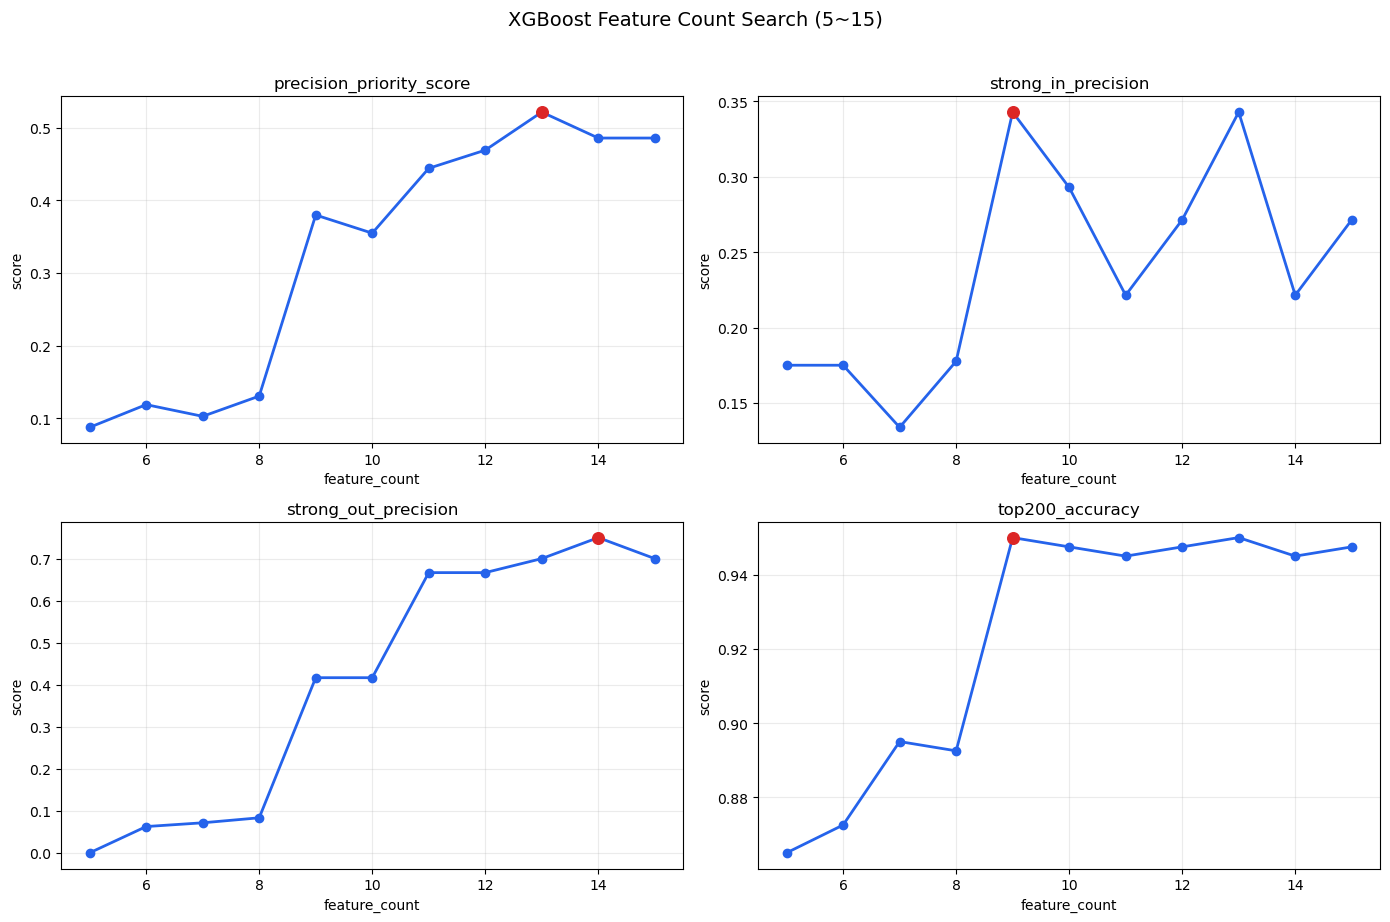

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_xgb_feature_search.png


In [18]:
plot_cols = [
    "precision_priority_score",
    "strong_in_precision",
    "strong_out_precision",
    "top200_accuracy",
]

xgb_plot_df = xgb_fine_summary_df.sort_values("feature_count").copy()
image_path = BASE_DIR / "images" / "v15_xgb_feature_search.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for metric, ax in zip(plot_cols, axes):
    ax.plot(xgb_plot_df["feature_count"], xgb_plot_df[metric], marker="o", linewidth=2, color="#2563EB")
    best_idx = xgb_plot_df[metric].idxmax()
    best_x = xgb_plot_df.loc[best_idx, "feature_count"]
    best_y = xgb_plot_df.loc[best_idx, metric]
    ax.scatter([best_x], [best_y], color="#DC2626", s=70, zorder=3)
    ax.set_title(metric)
    ax.set_xlabel("feature_count")
    ax.set_ylabel("score")
    ax.grid(alpha=0.25)

plt.suptitle("XGBoost Feature Count Search (5~15)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


In [19]:
xgb_best_feature_count = int(xgb_fine_summary_df.iloc[0]["feature_count"])
xgb_best_features = ranked_feature_list[:xgb_best_feature_count]

xgb_best_feature_df = pd.DataFrame(
    {
        "rank": list(range(1, len(xgb_best_features) + 1)),
        "feature": xgb_best_features,
        "source": [
            "core" if feature in v1_core_features else "candidate"
            for feature in xgb_best_features
        ],
    }
)

print("best_xgb_feature_count:", xgb_best_feature_count)
xgb_best_feature_df


best_xgb_feature_count: 13


,rank,feature,source
0,1,period_rank,core
1,2,sector_rank,core
2,3,foreign_change,core
3,4,turnover_ratio,core
4,5,rank_change,core
5,6,sector_relative_rank,core
6,7,major_holder_ratio,core
7,8,float_dist_from_200,candidate
8,9,prev_was_member,core
9,10,avg_mktcap,core


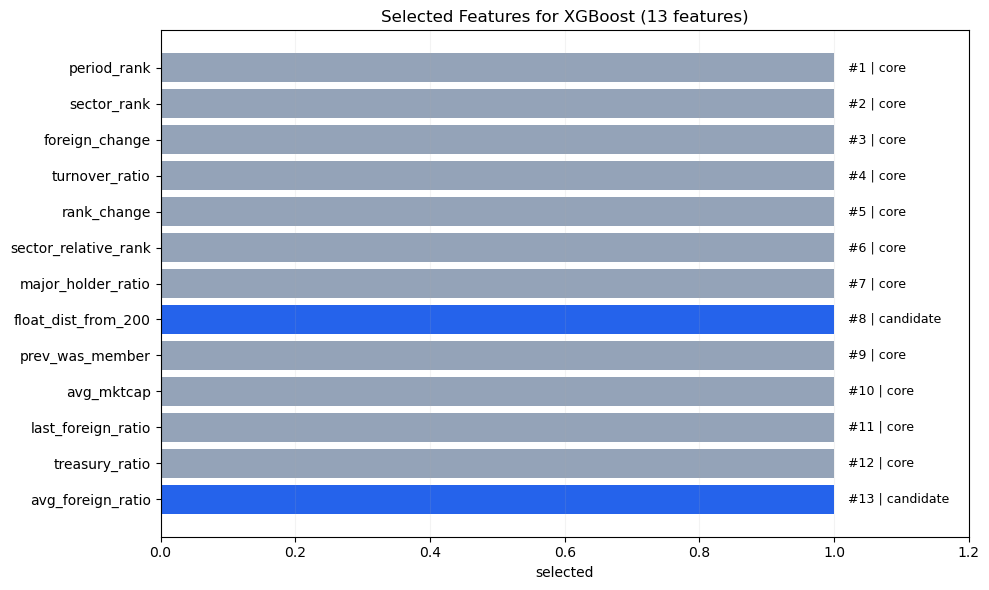

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_xgb_11_features.png


In [20]:
feature_source_plot_df = xgb_best_feature_df.copy()
feature_source_plot_df = feature_source_plot_df.sort_values("rank", ascending=True)
feature_colors = feature_source_plot_df["source"].map({"core": "#94A3B8", "candidate": "#2563EB"}).fillna("#64748B")
image_path = BASE_DIR / "images" / "v15_xgb_11_features.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_source_plot_df["feature"], [1] * len(feature_source_plot_df), color=feature_colors)
ax.invert_yaxis()
ax.set_title(f"Selected Features for XGBoost ({xgb_best_feature_count} features)")
ax.set_xlabel("selected")
ax.set_xlim(0, 1.2)
ax.grid(axis="x", alpha=0.15)

for i, (_, row) in enumerate(feature_source_plot_df.iterrows()):
    ax.text(1.02, i, f"#{int(row['rank'])} | {row['source']}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


## 31. 최종 3개 모델 집중 비교

여기서는 `XGBoost`, `LightGBM`, `ExtraTrees`만 놓고,
각 모델의 가장 유리한 피처 개수 구간을 비교합니다.

현재는 coarse search 결과를 기준으로 비교하지만,
필요하면 `LightGBM`, `ExtraTrees`도 이후에 `5~15` 세부 탐색으로 확장할 수 있습니다.


In [21]:
focused_compare_df = coarse_model_summary_df[
    coarse_model_summary_df["model"].isin(["XGBoost", "LightGBM", "ExtraTrees"])
].copy()

focused_compare_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
14,XGBoost,15,0.485714,0.271429,0.700000,0.9475,0.985,0.9475,103.420581,219.603175,142.845238
1,ExtraTrees,10,0.392857,0.369048,0.416667,0.9575,0.995,0.9575,102.401692,220.190476,161.250000
13,XGBoost,10,0.354762,0.292857,0.416667,0.9475,0.990,0.9475,103.256136,219.555556,148.023810
2,ExtraTrees,15,0.283333,0.400000,0.166667,0.9550,0.990,0.9550,102.495051,224.039683,159.833333
5,LightGBM,15,0.260714,0.271429,0.250000,0.9475,0.985,0.9475,103.757778,223.928571,145.154762
4,LightGBM,10,0.211039,0.279221,0.142857,0.9450,0.985,0.9450,103.352828,221.666667,151.273810
0,ExtraTrees,5,0.120455,0.150000,0.090909,0.8775,0.980,0.8775,108.995076,182.396825,192.178571
12,XGBoost,5,0.087500,0.175000,0.000000,0.8650,0.980,0.8650,109.750985,178.674603,189.642857
3,LightGBM,5,0.075000,0.150000,0.000000,0.8650,0.970,0.8650,110.129343,180.595238,191.809524


In [22]:
focused_best_by_model_df = (
    focused_compare_df.sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

focused_best_by_model_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
0,XGBoost,15,0.485714,0.271429,0.700000,0.9475,0.985,0.9475,103.420581,219.603175,142.845238
1,ExtraTrees,10,0.392857,0.369048,0.416667,0.9575,0.995,0.9575,102.401692,220.190476,161.250000
2,LightGBM,15,0.260714,0.271429,0.250000,0.9475,0.985,0.9475,103.757778,223.928571,145.154762


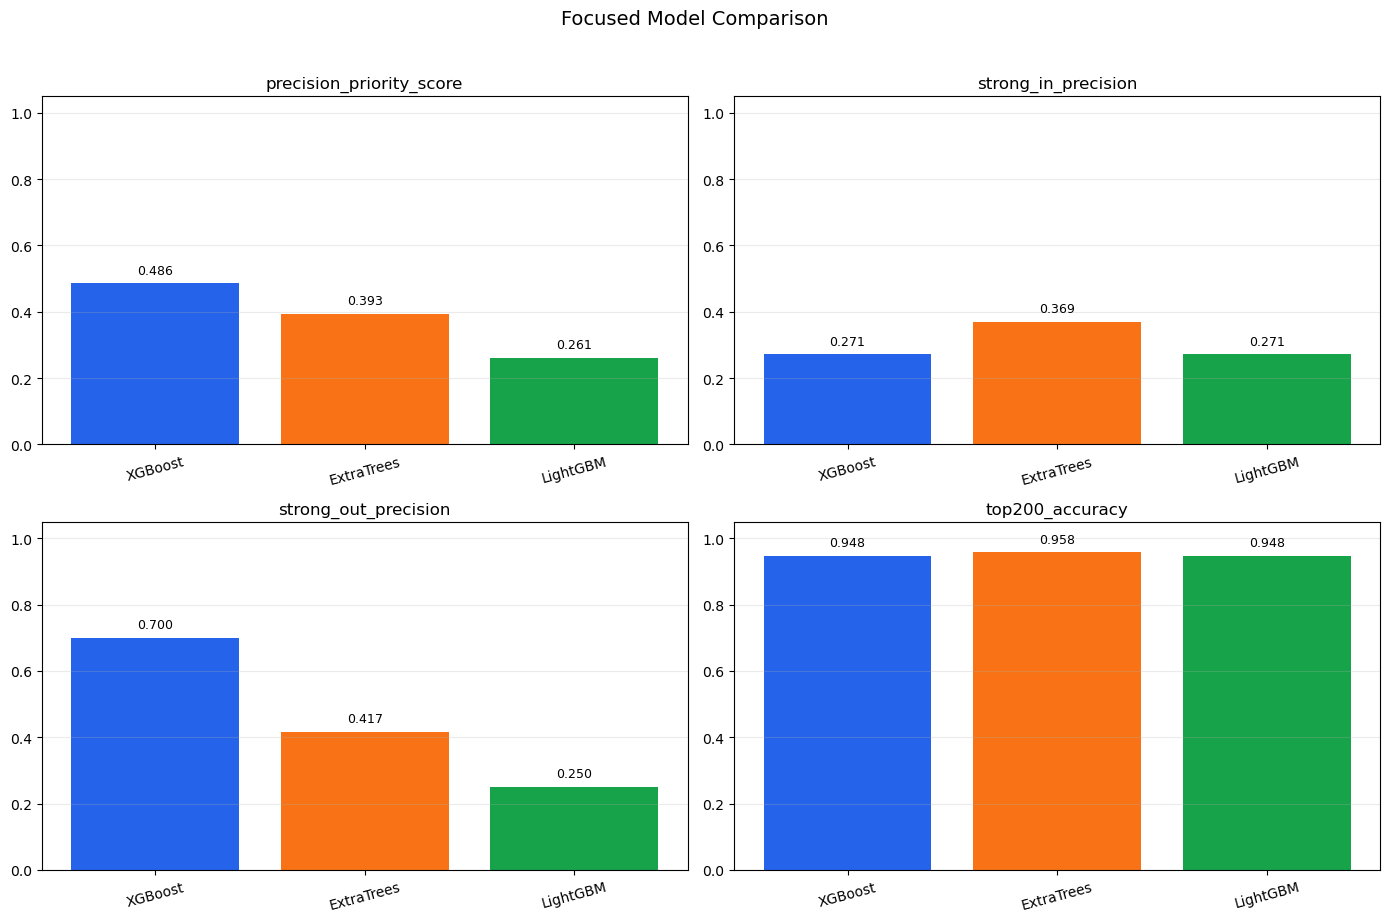

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_model_compare_top3.png


In [23]:
compare_metrics = [
    "precision_priority_score",
    "strong_in_precision",
    "strong_out_precision",
    "top200_accuracy",
]

model_plot_df = focused_best_by_model_df[["model"] + compare_metrics].copy().set_index("model")
image_path = BASE_DIR / "images" / "v15_model_compare_top3.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
colors = {"XGBoost": "#2563EB", "LightGBM": "#16A34A", "ExtraTrees": "#F97316"}

for metric, ax in zip(compare_metrics, axes):
    vals = model_plot_df[metric]
    ax.bar(vals.index, vals.values, color=[colors.get(name, "#94A3B8") for name in vals.index])
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Focused Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


In [24]:
focused_best_feature_map = {}
for _, row in focused_best_by_model_df.iterrows():
    model_name = row["model"]
    feature_count = int(row["feature_count"])
    focused_best_feature_map[model_name] = ranked_feature_list[:feature_count]

focused_best_feature_rows = []
for model_name, features in focused_best_feature_map.items():
    for rank, feature in enumerate(features, start=1):
        focused_best_feature_rows.append(
            {
                "model": model_name,
                "feature_count": len(features),
                "rank": rank,
                "feature": feature,
                "source": "core" if feature in v1_core_features else "candidate",
            }
        )

focused_best_feature_detail_df = pd.DataFrame(focused_best_feature_rows)
focused_best_feature_detail_df


,model,feature_count,rank,feature,source
0,XGBoost,15,1,period_rank,core
1,XGBoost,15,2,sector_rank,core
2,XGBoost,15,3,foreign_change,core
3,XGBoost,15,4,turnover_ratio,core
4,XGBoost,15,5,rank_change,core
5,XGBoost,15,6,sector_relative_rank,core
6,XGBoost,15,7,major_holder_ratio,core
7,XGBoost,15,8,float_dist_from_200,candidate
8,XGBoost,15,9,prev_was_member,core
9,XGBoost,15,10,avg_mktcap,core


## 33. v1 vs v1.5 최종 후보 직접 비교

In [25]:
v1_feature_list = list(pkg.get("features", []))

if "xgb_best_feature_count" not in globals():
    raise RuntimeError("먼저 XGBoost 집중 탐색 셀을 실행해서 xgb_best_feature_count를 만들어야 합니다.")

v1_5_best_feature_list = ranked_feature_list[:xgb_best_feature_count]

comparison_feature_sets_df = pd.DataFrame(
    [
        {
            "version": "v1",
            "model": "LightGBM",
            "feature_count": len(v1_feature_list),
            "feature_list": ", ".join(v1_feature_list),
        },
        {
            "version": "v1.5_best",
            "model": "XGBoost",
            "feature_count": len(v1_5_best_feature_list),
            "feature_list": ", ".join(v1_5_best_feature_list),
        },
    ]
)
comparison_feature_sets_df


,version,model,feature_count,feature_list
0,v1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio"
1,v1.5_best,XGBoost,13,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200, prev_was_member, avg_mktcap, last_foreign_ratio, treasury_rati..."


In [26]:
final_compare_frames = []

final_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in final_model_map.items():
    result_df = fit_and_score_model(
        model_name=model_name,
        model=model,
        feature_list=feature_list,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    result_df["version"] = version_name
    final_compare_frames.append(result_df)

v1_vs_v1_5_period_df = pd.concat(final_compare_frames, ignore_index=True)
v1_vs_v1_5_period_df["precision_priority_score"] = (
    v1_vs_v1_5_period_df["strong_in_precision"] + v1_vs_v1_5_period_df["strong_out_precision"]
) / 2.0

v1_vs_v1_5_period_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,version,precision_priority_score
0,0.945,0.142857,0.000000,104.610000,234.333333,153.142857,0.98,0.945,2025_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.071429
1,0.950,0.400000,0.333333,102.404040,210.571429,154.833333,0.98,0.950,2025_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.366667
2,0.950,0.285714,1.000000,104.715000,232.888889,140.571429,0.98,0.950,2025_H1,XGBoost,13,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200, prev_was_member, avg_mktcap, last_foreign_ratio, treasury_rati...",v1.5_best,0.642857
3,0.950,0.400000,0.400000,102.641414,209.571429,136.500000,0.98,0.950,2025_H2,XGBoost,13,"period_rank, sector_rank, foreign_change, turnover_ratio, rank_change, sector_relative_rank, major_holder_ratio, float_dist_from_200, prev_was_member, avg_mktcap, last_foreign_ratio, treasury_rati...",v1.5_best,0.400000


In [27]:
v1_vs_v1_5_summary_df = (
    v1_vs_v1_5_period_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
v1_vs_v1_5_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.521429,0.342857,0.700000,0.9500,0.98,0.9500,103.678207,221.230159,138.535714
0,v1,LightGBM,0.219048,0.271429,0.166667,0.9475,0.98,0.9475,103.507020,222.452381,153.988095


In [28]:
v1_vs_v1_5_delta_df = v1_vs_v1_5_summary_df.set_index("version").copy()

if {"v1", "v1.5_best"}.issubset(v1_vs_v1_5_delta_df.index):
    delta_row = (
        v1_vs_v1_5_delta_df.loc["v1.5_best"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
        - v1_vs_v1_5_delta_df.loc["v1"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
    )
    v1_vs_v1_5_delta_view_df = delta_row.to_frame("v1.5_minus_v1").reset_index().rename(columns={"index": "metric"})
else:
    v1_vs_v1_5_delta_view_df = pd.DataFrame()

v1_vs_v1_5_delta_view_df


,metric,v1.5_minus_v1
0,precision_priority_score,0.302381
1,strong_in_precision,0.071429
2,strong_out_precision,0.533333
3,top200_accuracy,0.0025
4,top100_member_precision,0.0
5,top200_member_precision,0.0025
6,actual_member_avg_pred_rank,0.171187
7,actual_in_avg_pred_rank,-1.222222
8,actual_out_avg_pred_rank,-15.452381


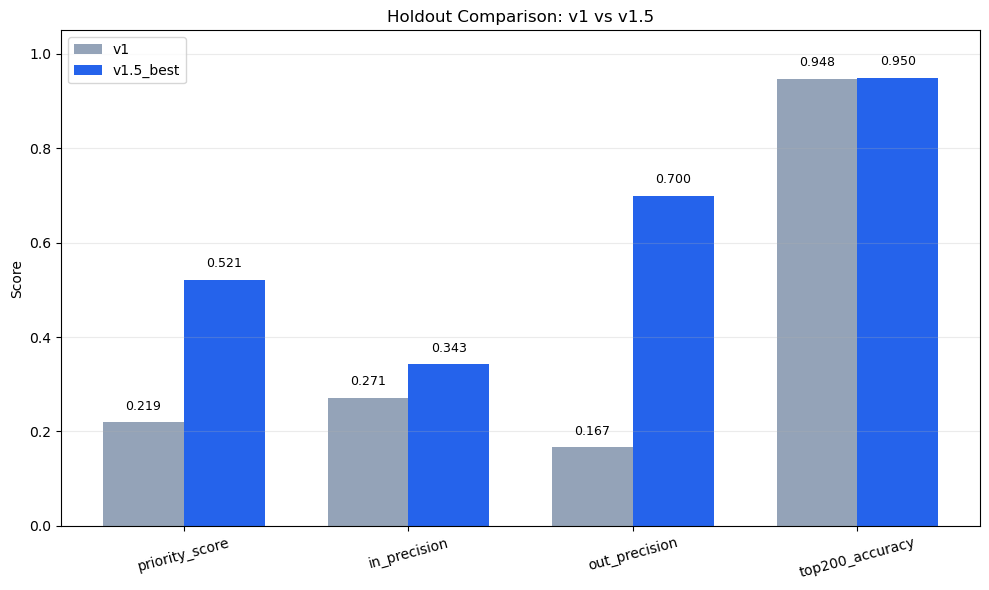

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_holdout_compare.png


In [29]:
required_metrics = [
    "precision_priority_score",
    "strong_in_precision",
    "strong_out_precision",
    "top200_accuracy",
]

plot_df = v1_vs_v1_5_summary_df[["version"] + required_metrics].copy()
plot_df = plot_df.set_index("version").loc[["v1", "v1.5_best"]]
image_path = BASE_DIR / "images" / "v15_holdout_compare.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(required_metrics))
width = 0.36

v1_vals = plot_df.loc["v1", required_metrics].values
v15_vals = plot_df.loc["v1.5_best", required_metrics].values

ax.bar(x - width / 2, v1_vals, width=width, label="v1", color="#94A3B8")
ax.bar(x + width / 2, v15_vals, width=width, label="v1.5_best", color="#2563EB")

ax.set_title("Holdout Comparison: v1 vs v1.5")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(["priority_score", "in_precision", "out_precision", "top200_accuracy"], rotation=15)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend()

for i, value in enumerate(v1_vals):
    ax.text(x[i] - width / 2, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
for i, value in enumerate(v15_vals):
    ax.text(x[i] + width / 2, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


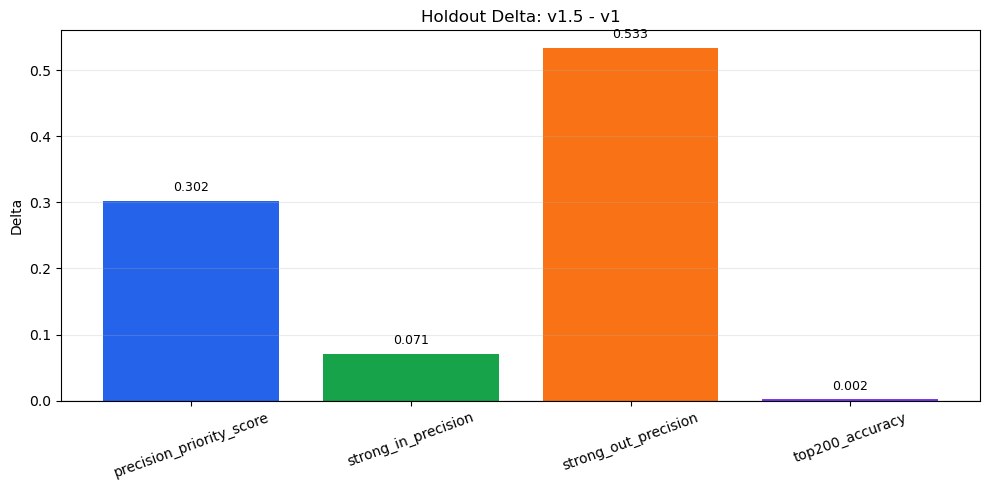

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_holdout_delta.png


In [30]:
delta_metrics = [
    "precision_priority_score",
    "strong_in_precision",
    "strong_out_precision",
    "top200_accuracy",
]

base_df = v1_vs_v1_5_summary_df.set_index("version").loc[["v1", "v1.5_best"], delta_metrics]
delta_series = base_df.loc["v1.5_best"] - base_df.loc["v1"]
delta_df = delta_series.reset_index()
delta_df.columns = ["metric", "delta"]
image_path = BASE_DIR / "images" / "v15_holdout_delta.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2563EB", "#16A34A", "#F97316", "#7C3AED"]
ax.bar(delta_df["metric"], delta_df["delta"], color=colors[: len(delta_df)])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Holdout Delta: v1.5 - v1")
ax.set_ylabel("Delta")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)

for i, v in enumerate(delta_df["delta"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


## 34. v1 대비 v1.5 최종 해석 메모

- `precision_priority_score`, `strong_in_precision`, `strong_out_precision`를 우선적으로 해석합니다.
- `top200_accuracy`와 `top100/top200_member_precision`은 구성 종목 분리력을 함께 보여줍니다.
- `actual_member_avg_pred_rank`, `actual_out_avg_pred_rank`는 낮을수록 더 좋은 rank 품질로 해석합니다.
- 최종 모델 선정 우선순위는 `precision > top200_accuracy > rank 품질`입니다.


## 35. 2020_H1 ~ 2025_H2 전체 기간 시각 비교

여기서는 `v1`과 `v1.5_best`를 전체 기간에 대해 시각적으로 비교합니다.

주의:
- 이 비교는 `2025_H1`, `2025_H2` 테스트 구간뿐 아니라 과거 기간도 함께 포함합니다.
- 따라서 `train 구간 포함 전체 흐름 시각화`로 해석하는 것이 맞습니다.
- 최종 일반화 성능 판단은 여전히 `test period` 결과를 우선합니다.

In [31]:
full_period_order = [period for period in historical_period_order if period != "2026_H1"]
full_period_order


['2020_H1',
 '2020_H2',
 '2021_H1',
 '2021_H2',
 '2022_H1',
 '2022_H2',
 '2023_H1',
 '2023_H2',
 '2024_H1',
 '2024_H2',
 '2025_H1',
 '2025_H2']

In [32]:
def score_full_periods(version_name: str, model_name: str, model, feature_list: list[str]) -> pd.DataFrame:
    X_train = train_snapshot_df[feature_list].fillna(0.0)
    y_train = train_snapshot_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    rows = []
    for period in full_period_order:
        period_frame = historical_snapshot_df[historical_snapshot_df["period"] == period].copy()
        if period_frame.empty:
            continue

        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")

        metric_row = evaluate_period_scores(period_frame)
        metric_row["period"] = period
        metric_row["model"] = model_name
        metric_row["feature_count"] = len(feature_list)
        metric_row["feature_list"] = ", ".join(feature_list)
        metric_row["version"] = version_name
        rows.append(metric_row)

    return pd.DataFrame(rows)


In [33]:
full_period_compare_frames = []

full_period_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in full_period_model_map.items():
    version_df = score_full_periods(version_name, model_name, model, feature_list)
    full_period_compare_frames.append(version_df)

full_period_compare_df = pd.concat(full_period_compare_frames, ignore_index=True)
full_period_compare_df["precision_priority_score"] = (
    full_period_compare_df["strong_in_precision"] + full_period_compare_df["strong_out_precision"]
) / 2.0

full_period_compare_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,version,precision_priority_score
0,0.945,0.222222,0.666667,102.690000,210.000000,175.000000,0.99,0.945,2020_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.444444
1,0.990,0.900000,1.000000,99.500000,191.111111,217.333333,1.00,0.990,2020_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.950000
2,0.980,0.666667,1.000000,98.500000,192.250000,210.833333,1.00,0.980,2021_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.833333
3,0.965,0.428571,1.000000,97.000000,192.000000,206.714286,1.00,0.965,2021_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,0.714286
4,0.985,1.000000,1.000000,99.000000,190.285714,210.625000,1.00,0.985,2022_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000
5,1.000,1.000000,1.000000,100.500000,200.000000,214.000000,1.00,1.000,2022_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000
6,1.000,1.000000,1.000000,100.500000,195.200000,209.000000,1.00,1.000,2023_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000
7,0.995,1.000000,1.000000,100.000000,195.250000,211.625000,1.00,0.995,2023_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000
8,0.985,1.000000,1.000000,99.000000,195.000000,203.714286,1.00,0.985,2024_H1,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000
9,0.995,1.000000,1.000000,100.000000,197.500000,216.400000,1.00,0.995,2024_H2,LightGBM,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1,1.000000


In [34]:
full_period_summary_df = (
    full_period_compare_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
full_period_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.825794,0.757143,0.894444,0.977917,0.995833,0.977917,100.286368,199.242229,194.395139
0,v1,LightGBM,0.781680,0.730026,0.833333,0.977917,0.995833,0.977917,100.308670,200.291799,198.601786


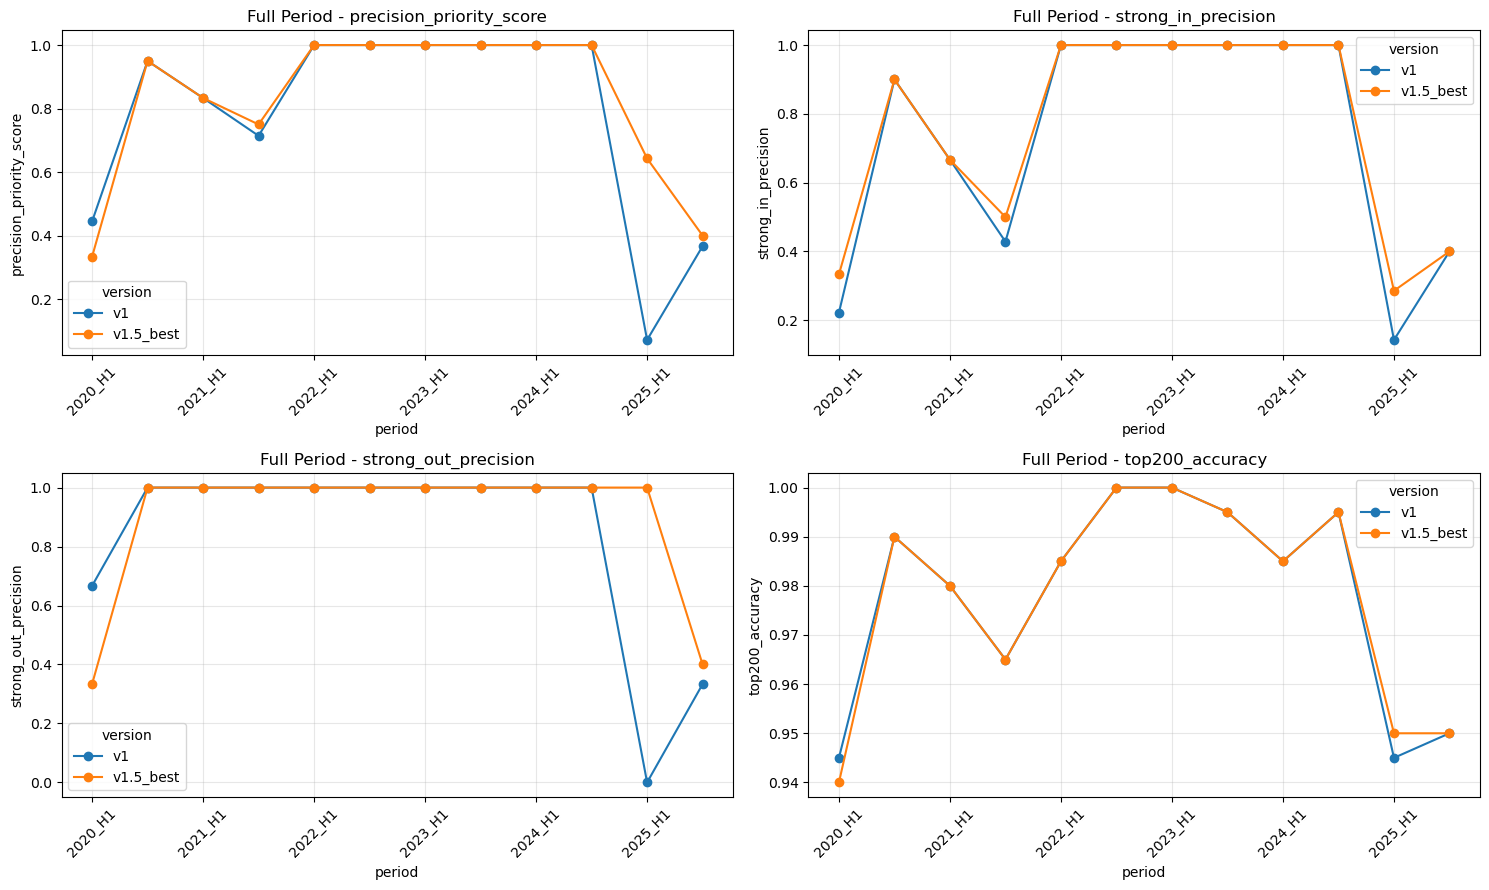

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_full_period_compare.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()
image_path = BASE_DIR / "images" / "v15_full_period_compare.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    plot_df = full_period_compare_df.pivot(index="period", columns="version", values=metric)
    plot_df = plot_df.reindex(full_period_order)
    plot_df.plot(marker="o", ax=ax)
    ax.set_title(f"Full Period - {metric}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("period")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


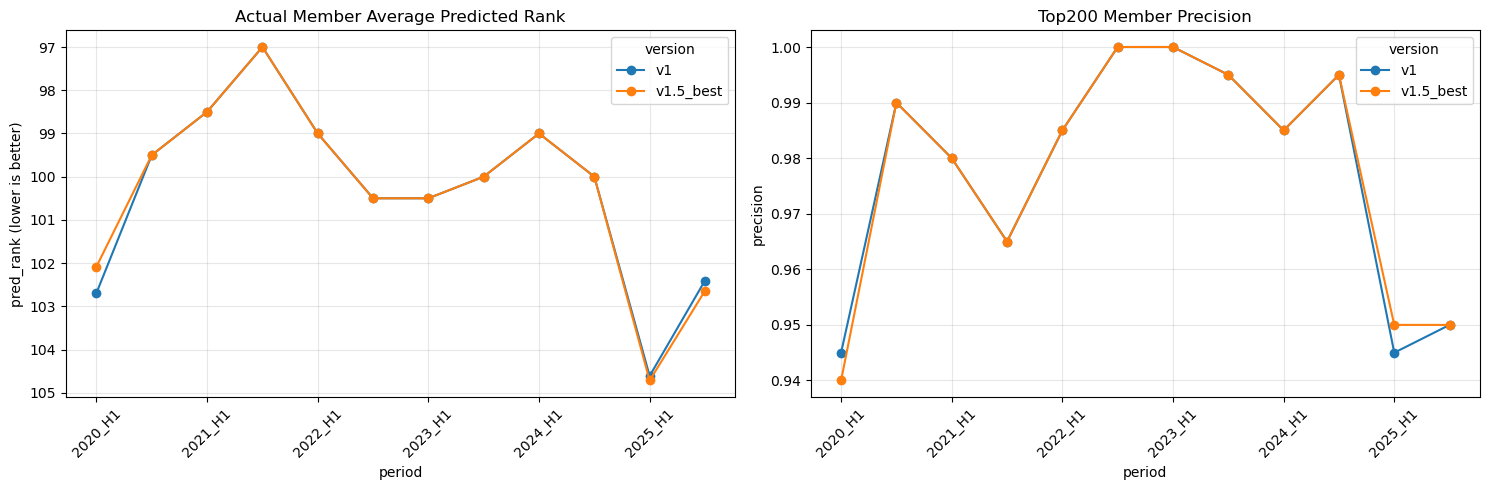

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_full_period_rank_quality.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
image_path = BASE_DIR / "images" / "v15_full_period_rank_quality.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

rank_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="actual_member_avg_pred_rank")
rank_plot_df = rank_plot_df.reindex(full_period_order)
rank_plot_df.plot(marker="o", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Actual Member Average Predicted Rank")
axes[0].set_ylabel("pred_rank (lower is better)")
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

top200_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="top200_member_precision")
top200_plot_df = top200_plot_df.reindex(full_period_order)
top200_plot_df.plot(marker="o", ax=axes[1])
axes[1].set_title("Top200 Member Precision")
axes[1].set_ylabel("precision")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


In [37]:
train_test_tag_df = pd.DataFrame(
    {
        "period": full_period_order,
        "split_type": [
            "train" if period in train_periods else "test" if period in test_periods else "other"
            for period in full_period_order
        ],
    }
)
train_test_tag_df


,period,split_type
0,2020_H1,other
1,2020_H2,train
2,2021_H1,train
3,2021_H2,train
4,2022_H1,train
5,2022_H2,train
6,2023_H1,train
7,2023_H2,train
8,2024_H1,train
9,2024_H2,train


### 전체 기간 보조 해석

- 내부 rank 품질(`Actual Member Average Predicted Rank`) 시각화는 이번 버전의 핵심 비교에서 제외합니다.
- 대신 아래 이벤트 성과 섹션에서 `predicted / actual / hit / missed_actual / false_positive`를 함께 확인합니다.

## 성능 해석 주의

- `Full Period` 비교 그래프는 **train period + test period**를 모두 포함합니다.
- 따라서 `1.0`에 가까운 precision 구간이 있더라도, 이것만으로 일반화 성능이라고 해석하면 안 됩니다.
- 실제 모델 선택의 핵심 근거는 **holdout (`2025_H1`, `2025_H2`) 성능**입니다.
- `Full Period` 그래프는 전체 구간 경향과 분리력을 보는 보조 시각화로 해석합니다.

## v1.5 이벤트 성과 시각화

아래 셀은 `v1.5_best = XGBoost + 11개 피처`를 기준으로, 이벤트 성과 지표를 다시 계산합니다.

- 기간별 `strong_in / strong_out / 벤치마크` 수익률
- 기간별 `strong_in / strong_out precision`
- 기간별 예측 수 / 실제 수 / 적중 수
- 기간별 `recall / missed_actual / false_positive`

In [38]:
def score_full_period_details(version_name: str, model_name: str, model, feature_list: list[str]) -> pd.DataFrame:
    X_train = train_snapshot_df[feature_list].fillna(0.0)
    y_train = train_snapshot_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    detail_frames = []
    for period in full_period_order:
        period_frame = historical_snapshot_df[historical_snapshot_df["period"] == period].copy()
        if period_frame.empty:
            continue

        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")

        pred_top200 = set(period_frame.nsmallest(200, "pred_rank")["ticker"])
        strong_in_df = (
            period_frame[
                (period_frame["prev_was_member"].astype(int) == 0)
                & (period_frame["ticker"].isin(pred_top200))
            ]
            .sort_values("pred_rank")
            .head(20)
            .copy()
        )
        strong_out_df = (
            period_frame[
                (period_frame["prev_was_member"].astype(int) == 1)
                & (period_frame["pred_rank"].between(201, 220))
            ]
            .sort_values("pred_rank")
            .head(20)
            .copy()
        )

        period_frame["pred_top200"] = period_frame["ticker"].isin(pred_top200).astype(int)
        period_frame["strong_in_pred"] = period_frame["ticker"].isin(set(strong_in_df["ticker"])).astype(int)
        period_frame["strong_out_pred"] = period_frame["ticker"].isin(set(strong_out_df["ticker"])).astype(int)
        period_frame["version"] = version_name
        period_frame["model"] = model_name
        detail_frames.append(period_frame)

    return pd.concat(detail_frames, ignore_index=True)


def get_next_observation(target_date, dates):
    target = pd.Timestamp(target_date)
    valid = dates[dates >= target]
    return valid[0] if len(valid) else pd.NaT


def get_prev_observation(target_date, dates):
    target = pd.Timestamp(target_date)
    valid = dates[dates <= target]
    return valid[-1] if len(valid) else pd.NaT


def get_second_friday(year: int, month: int) -> pd.Timestamp:
    first_day = pd.Timestamp(year=year, month=month, day=1)
    days_to_friday = (4 - first_day.weekday()) % 7
    first_friday = first_day + pd.Timedelta(days=days_to_friday)
    return first_friday + pd.Timedelta(weeks=1)


def build_calendar(period: str, dates: pd.DatetimeIndex) -> dict:
    year = int(period[:4])
    half = period[-2:]
    buy_ref = pd.Timestamp(year=year, month=5 if half == "H1" else 11, day=1)
    sell_ref = get_second_friday(year, 6 if half == "H1" else 12)
    return {
        "buy_reference": buy_ref,
        "sell_reference": sell_ref,
        "buy_date": get_next_observation(buy_ref, dates),
        "sell_date": get_prev_observation(sell_ref, dates),
    }


def compute_returns_for_subset(subset: pd.DataFrame, buy_date: pd.Timestamp, sell_date: pd.Timestamp, price_frame: pd.DataFrame):
    if subset.empty or pd.isna(buy_date) or pd.isna(sell_date):
        result = subset.copy()
        result["buy_price"] = np.nan
        result["sell_price"] = np.nan
        result["return_pct"] = np.nan
        return result

    buy_prices = (
        price_frame.loc[price_frame["date"] == buy_date, ["ticker", "close"]]
        .rename(columns={"close": "buy_price"})
        .drop_duplicates(subset=["ticker"])
    )
    sell_prices = (
        price_frame.loc[price_frame["date"] == sell_date, ["ticker", "close"]]
        .rename(columns={"close": "sell_price"})
        .drop_duplicates(subset=["ticker"])
    )
    result = subset.merge(buy_prices, on="ticker", how="left").merge(sell_prices, on="ticker", how="left")
    result["return_pct"] = (result["sell_price"] - result["buy_price"]) / result["buy_price"] * 100
    return result


def calc_signal_metrics(period_df, signal_col, label_col):
    predicted_df = period_df.loc[period_df[signal_col] == 1].copy()
    actual_df = period_df.loc[period_df[label_col].fillna(0) == 1].copy()

    predicted_set = set(predicted_df["ticker"])
    actual_set = set(actual_df["ticker"])
    hit_set = predicted_set & actual_set

    precision = (len(hit_set) / len(predicted_set) * 100) if predicted_set else np.nan
    return {
        "pred_count": int(len(predicted_set)),
        "actual_count": int(len(actual_set)),
        "hit_count": int(len(hit_set)),
        "precision_pct": precision,
    }


v15_detail_df = score_full_period_details(
    version_name="v1.5_best",
    model_name="XGBoost",
    model=XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        n_jobs=1,
    ),
    feature_list=v1_5_best_feature_list,
)

friday_prices_v15 = load_table(sql_path, "kospi_friday_daily").copy()
friday_prices_v15["ticker"] = friday_prices_v15["ticker"].astype(str).str.zfill(6)
friday_prices_v15["date"] = pd.to_datetime(friday_prices_v15["date"].astype(str), errors="coerce")
price_v15 = friday_prices_v15[["date", "ticker", "close"]].dropna().drop_duplicates()
observation_days_v15 = pd.DatetimeIndex(sorted(price_v15["date"].unique()))

v15_return_rows = []
v15_precision_rows = []

for period in full_period_order:
    period_df = v15_detail_df.loc[v15_detail_df["period"] == period].copy()
    if period_df.empty:
        continue

    calendar = build_calendar(period, observation_days_v15)

    strong_in_df = compute_returns_for_subset(
        period_df.loc[period_df["strong_in_pred"] == 1].copy(),
        calendar["buy_date"],
        calendar["sell_date"],
        price_v15,
    )
    strong_out_df = compute_returns_for_subset(
        period_df.loc[period_df["strong_out_pred"] == 1].copy(),
        calendar["buy_date"],
        calendar["sell_date"],
        price_v15,
    )
    benchmark_df = compute_returns_for_subset(
        period_df.loc[period_df["prev_was_member"].fillna(0).astype(int) == 1, ["ticker", "prev_was_member"]].copy(),
        calendar["buy_date"],
        calendar["sell_date"],
        price_v15,
    )

    v15_return_rows.append({
        "period": period,
        "strong_in_avg_return": strong_in_df["return_pct"].mean(),
        "strong_out_avg_return": strong_out_df["return_pct"].mean(),
        "benchmark_avg_return": benchmark_df["return_pct"].mean(),
        "strong_in_count": int(len(strong_in_df)),
        "strong_out_count": int(len(strong_out_df)),
    })

    in_metrics = calc_signal_metrics(period_df, "strong_in_pred", "label_in")
    out_metrics = calc_signal_metrics(period_df, "strong_out_pred", "label_out")
    v15_precision_rows.append({
        "period": period,
        "strong_in_precision_pct": in_metrics["precision_pct"],
        "strong_out_precision_pct": out_metrics["precision_pct"],
        "strong_in_count": in_metrics["pred_count"],
        "strong_in_actual_count": in_metrics["actual_count"],
        "strong_in_hit": in_metrics["hit_count"],
        "strong_out_count": out_metrics["pred_count"],
        "strong_out_actual_count": out_metrics["actual_count"],
        "strong_out_hit": out_metrics["hit_count"],
    })

v15_return_summary_df = pd.DataFrame(v15_return_rows)
v15_precision_summary_df = pd.DataFrame(v15_precision_rows)

v15_return_summary_df



,period,strong_in_avg_return,strong_out_avg_return,benchmark_avg_return,strong_in_count,strong_out_count
0,2020_H1,8.470871,26.350005,8.300179,12,6
1,2020_H2,23.267963,3.933350,12.339444,10,4
2,2021_H1,31.160453,7.095057,3.956437,6,3
3,2021_H2,-5.073443,7.662756,-2.432958,6,3
4,2022_H1,-9.691665,-5.224318,-1.253080,7,3
5,2022_H2,-8.333333,11.616954,5.712073,1,1
6,2023_H1,3.090588,-7.382639,7.254269,5,5
7,2023_H2,5.636994,8.230551,7.388963,8,6
8,2024_H1,8.690940,-7.531819,2.469961,5,4
9,2024_H2,1.342816,-16.458751,-3.329579,4,3


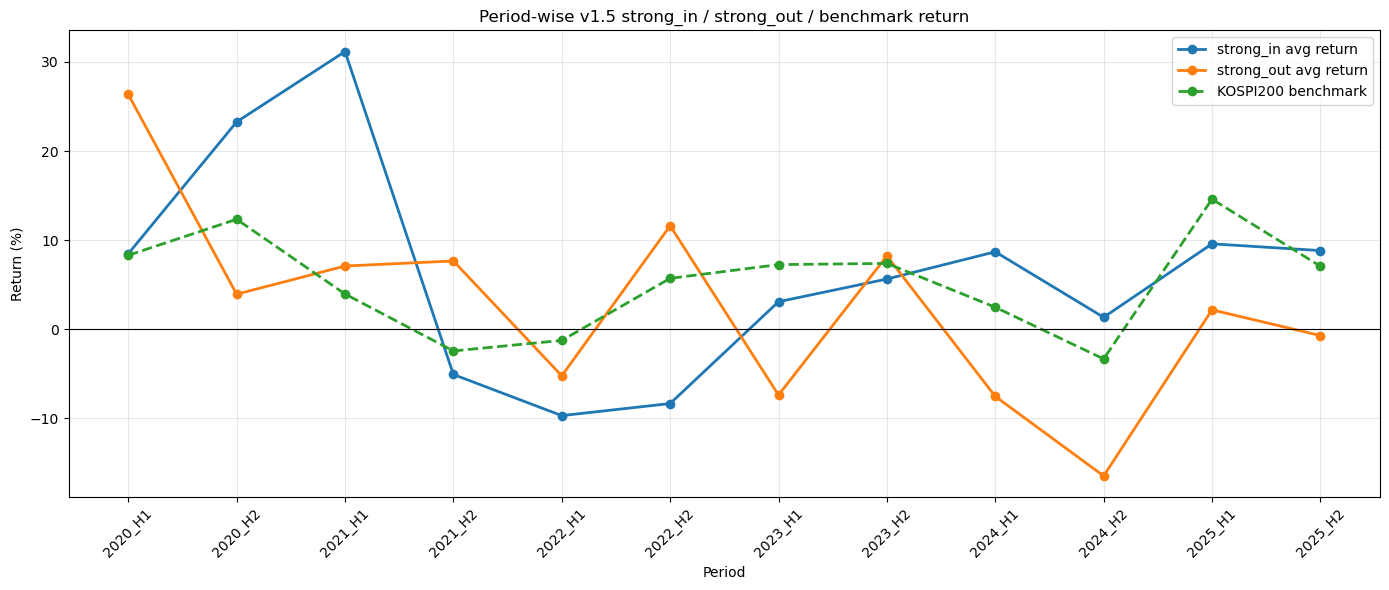

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_event_return.png


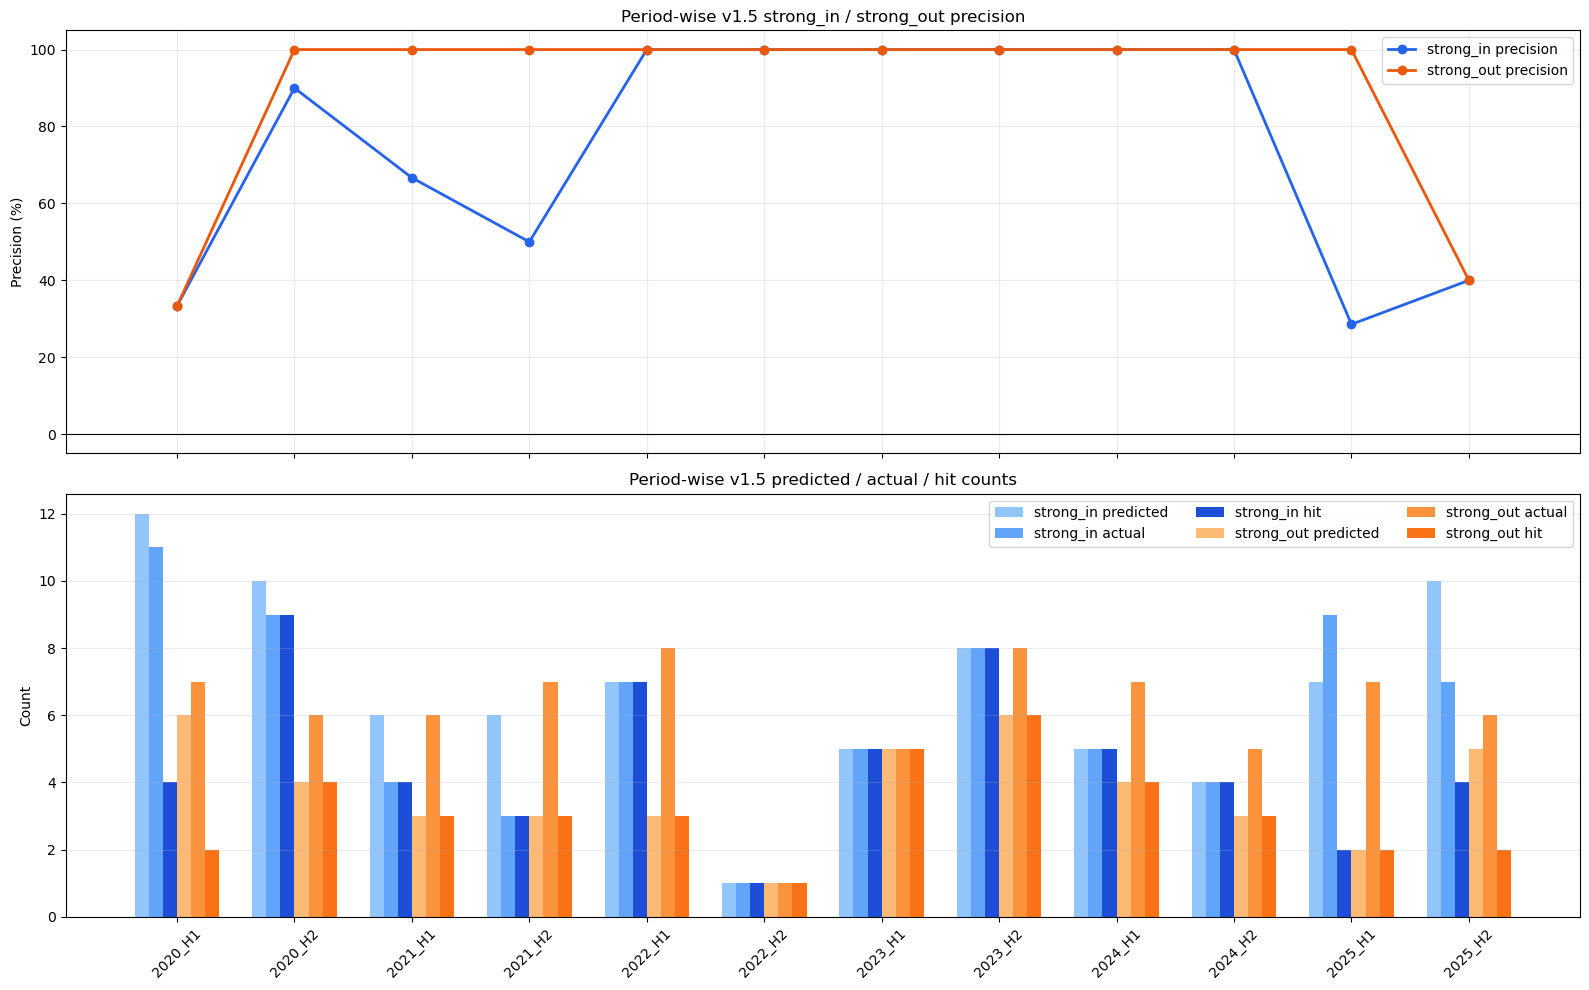

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_event_precision.png


,period,strong_in_precision_pct,strong_out_precision_pct,strong_in_count,strong_in_actual_count,strong_in_hit,strong_out_count,strong_out_actual_count,strong_out_hit
0,2020_H1,33.333333,33.333333,12,11,4,6,7,2
1,2020_H2,90.000000,100.000000,10,9,9,4,6,4
2,2021_H1,66.666667,100.000000,6,4,4,3,6,3
3,2021_H2,50.000000,100.000000,6,3,3,3,7,3
4,2022_H1,100.000000,100.000000,7,7,7,3,8,3
5,2022_H2,100.000000,100.000000,1,1,1,1,1,1
6,2023_H1,100.000000,100.000000,5,5,5,5,5,5
7,2023_H2,100.000000,100.000000,8,8,8,6,8,6
8,2024_H1,100.000000,100.000000,5,5,5,4,7,4
9,2024_H2,100.000000,100.000000,4,4,4,3,5,3


In [39]:
image_path_return = BASE_DIR / "images" / "v15_event_return.png"
image_path_precision = BASE_DIR / "images" / "v15_event_precision.png"
image_path_return.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))
plot_df = v15_return_summary_df.copy()
ax.plot(plot_df["period"], plot_df["strong_in_avg_return"], marker="o", linewidth=2, label="strong_in avg return")
ax.plot(plot_df["period"], plot_df["strong_out_avg_return"], marker="o", linewidth=2, label="strong_out avg return")
ax.plot(plot_df["period"], plot_df["benchmark_avg_return"], marker="o", linewidth=2, linestyle="--", label="KOSPI200 benchmark")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Period-wise v1.5 strong_in / strong_out / benchmark return")
ax.set_xlabel("Period")
ax.set_ylabel("Return (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(image_path_return, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path_return}")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
plot_stats = v15_precision_summary_df.copy()
x = np.arange(len(plot_stats))
axes[0].plot(plot_stats["period"].astype(str), plot_stats["strong_in_precision_pct"], marker="o", linewidth=2, color="#2563EB", label="strong_in precision")
axes[0].plot(plot_stats["period"].astype(str), plot_stats["strong_out_precision_pct"], marker="o", linewidth=2, color="#EA580C", label="strong_out precision")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Precision (%)")
axes[0].set_title("Period-wise v1.5 strong_in / strong_out precision")
axes[0].grid(alpha=0.25)
axes[0].legend()

width = 0.12
axes[1].bar(x - width * 2.5, plot_stats["strong_in_count"], width=width, color="#93C5FD", label="strong_in predicted")
axes[1].bar(x - width * 1.5, plot_stats["strong_in_actual_count"], width=width, color="#60A5FA", label="strong_in actual")
axes[1].bar(x - width * 0.5, plot_stats["strong_in_hit"], width=width, color="#1D4ED8", label="strong_in hit")
axes[1].bar(x + width * 0.5, plot_stats["strong_out_count"], width=width, color="#FDBA74", label="strong_out predicted")
axes[1].bar(x + width * 1.5, plot_stats["strong_out_actual_count"], width=width, color="#FB923C", label="strong_out actual")
axes[1].bar(x + width * 2.5, plot_stats["strong_out_hit"], width=width, color="#F97316", label="strong_out hit")
axes[1].set_ylabel("Count")
axes[1].set_title("Period-wise v1.5 predicted / actual / hit counts")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_stats["period"].astype(str), rotation=45)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(image_path_precision, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path_precision}")

v15_precision_summary_df


## recall / missed_actual / false_positive 추가 확인

아래 표와 그래프는 `precision`만으로는 보이지 않는 정보를 같이 보여줍니다.

- `recall`: 실제 편입/편출 종목 중 얼마나 맞췄는가
- `missed_actual`: 실제 발생했지만 예측하지 못한 종목 수
- `false_positive`: 예측했지만 실제로는 발생하지 않은 종목 수
- 이 정보를 함께 보면 `precision 100%`가 실제 전체 이벤트를 모두 맞췄다는 뜻은 아니라는 점을 확인할 수 있습니다.

In [40]:
v15_coverage_summary_df = v15_precision_summary_df.copy()

v15_coverage_summary_df["strong_in_recall_pct"] = np.where(
    v15_coverage_summary_df["strong_in_actual_count"] > 0,
    v15_coverage_summary_df["strong_in_hit"] / v15_coverage_summary_df["strong_in_actual_count"] * 100,
    np.nan,
)
v15_coverage_summary_df["strong_out_recall_pct"] = np.where(
    v15_coverage_summary_df["strong_out_actual_count"] > 0,
    v15_coverage_summary_df["strong_out_hit"] / v15_coverage_summary_df["strong_out_actual_count"] * 100,
    np.nan,
)

v15_coverage_summary_df["strong_in_missed_actual"] = (
    v15_coverage_summary_df["strong_in_actual_count"] - v15_coverage_summary_df["strong_in_hit"]
).clip(lower=0)
v15_coverage_summary_df["strong_out_missed_actual"] = (
    v15_coverage_summary_df["strong_out_actual_count"] - v15_coverage_summary_df["strong_out_hit"]
).clip(lower=0)

v15_coverage_summary_df["strong_in_false_positive"] = (
    v15_coverage_summary_df["strong_in_count"] - v15_coverage_summary_df["strong_in_hit"]
).clip(lower=0)
v15_coverage_summary_df["strong_out_false_positive"] = (
    v15_coverage_summary_df["strong_out_count"] - v15_coverage_summary_df["strong_out_hit"]
).clip(lower=0)

coverage_columns = [
    "period",
    "strong_in_count",
    "strong_in_actual_count",
    "strong_in_hit",
    "strong_in_precision_pct",
    "strong_in_recall_pct",
    "strong_in_missed_actual",
    "strong_in_false_positive",
    "strong_out_count",
    "strong_out_actual_count",
    "strong_out_hit",
    "strong_out_precision_pct",
    "strong_out_recall_pct",
    "strong_out_missed_actual",
    "strong_out_false_positive",
]

v15_coverage_summary_df[coverage_columns]


,period,strong_in_count,strong_in_actual_count,strong_in_hit,strong_in_precision_pct,strong_in_recall_pct,strong_in_missed_actual,strong_in_false_positive,strong_out_count,strong_out_actual_count,strong_out_hit,strong_out_precision_pct,strong_out_recall_pct,strong_out_missed_actual,strong_out_false_positive
0,2020_H1,12,11,4,33.333333,36.363636,7,8,6,7,2,33.333333,28.571429,5,4
1,2020_H2,10,9,9,90.000000,100.000000,0,1,4,6,4,100.000000,66.666667,2,0
2,2021_H1,6,4,4,66.666667,100.000000,0,2,3,6,3,100.000000,50.000000,3,0
3,2021_H2,6,3,3,50.000000,100.000000,0,3,3,7,3,100.000000,42.857143,4,0
4,2022_H1,7,7,7,100.000000,100.000000,0,0,3,8,3,100.000000,37.500000,5,0
5,2022_H2,1,1,1,100.000000,100.000000,0,0,1,1,1,100.000000,100.000000,0,0
6,2023_H1,5,5,5,100.000000,100.000000,0,0,5,5,5,100.000000,100.000000,0,0
7,2023_H2,8,8,8,100.000000,100.000000,0,0,6,8,6,100.000000,75.000000,2,0
8,2024_H1,5,5,5,100.000000,100.000000,0,0,4,7,4,100.000000,57.142857,3,0
9,2024_H2,4,4,4,100.000000,100.000000,0,0,3,5,3,100.000000,60.000000,2,0


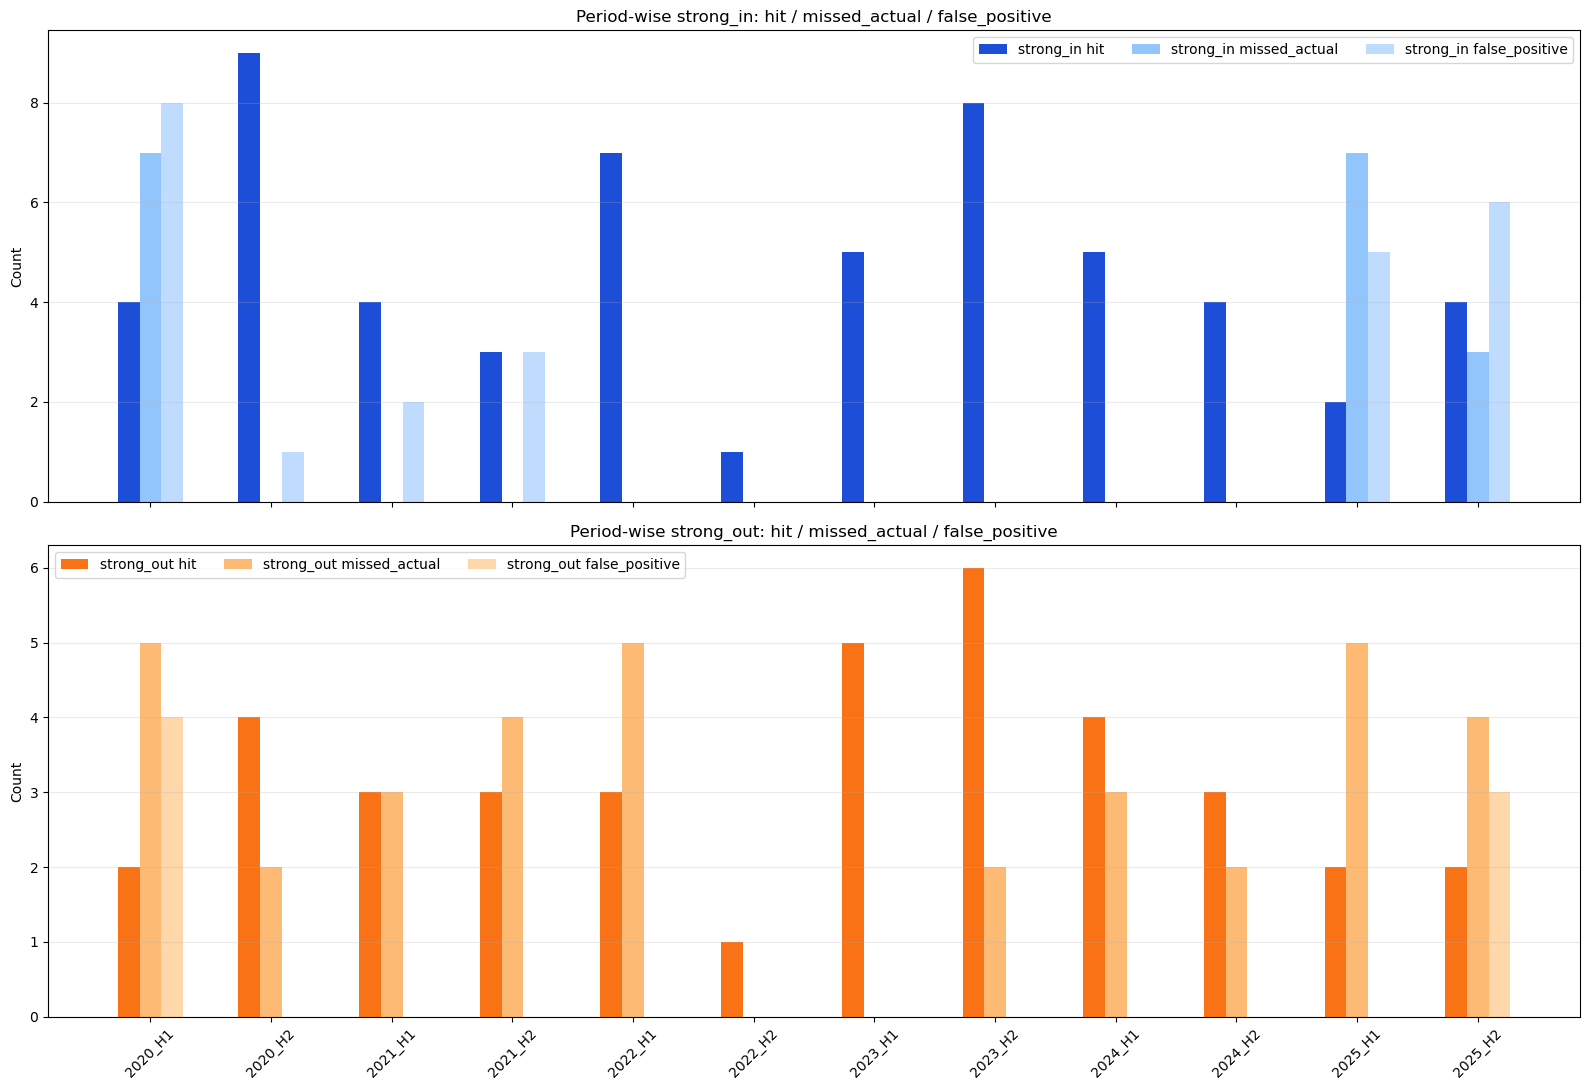

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_event_coverage.png


In [41]:
image_path = BASE_DIR / "images" / "v15_event_coverage.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

plot_df = v15_coverage_summary_df.copy()
x = np.arange(len(plot_df))
width = 0.18

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

axes[0].bar(x - width, plot_df["strong_in_hit"], width=width, color="#1D4ED8", label="strong_in hit")
axes[0].bar(x, plot_df["strong_in_missed_actual"], width=width, color="#93C5FD", label="strong_in missed_actual")
axes[0].bar(x + width, plot_df["strong_in_false_positive"], width=width, color="#BFDBFE", label="strong_in false_positive")
axes[0].set_title("Period-wise strong_in: hit / missed_actual / false_positive")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(ncol=3)

axes[1].bar(x - width, plot_df["strong_out_hit"], width=width, color="#F97316", label="strong_out hit")
axes[1].bar(x, plot_df["strong_out_missed_actual"], width=width, color="#FDBA74", label="strong_out missed_actual")
axes[1].bar(x + width, plot_df["strong_out_false_positive"], width=width, color="#FED7AA", label="strong_out false_positive")
axes[1].set_title("Period-wise strong_out: hit / missed_actual / false_positive")
axes[1].set_ylabel("Count")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["period"].astype(str), rotation=45)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(ncol=3)

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


## 반기별 confusion matrix 시각화

아래 그림은 각 반기마다 `strong_in`, `strong_out` 예측에 대한 2x2 confusion matrix를 직접 보여줍니다.

- `TP`: 예측했고 실제로 발생한 종목
- `FP`: 예측했지만 실제로는 발생하지 않은 종목
- `FN`: 실제 발생했지만 예측하지 못한 종목
- `TN`: 나머지 종목

In [42]:
def build_confusion_summary(detail_df: pd.DataFrame, pred_col: str, label_col: str) -> pd.DataFrame:
    rows = []
    for period, period_df in detail_df.groupby("period"):
        y_pred = period_df[pred_col].fillna(0).astype(int)
        y_true = period_df[label_col].fillna(0).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        tn = int(((y_pred == 0) & (y_true == 0)).sum())
        rows.append({"period": period, "TP": tp, "FP": fp, "FN": fn, "TN": tn})
    return pd.DataFrame(rows).sort_values("period").reset_index(drop=True)

strong_in_confusion_df = build_confusion_summary(v15_detail_df, "strong_in_pred", "label_in")
strong_out_confusion_df = build_confusion_summary(v15_detail_df, "strong_out_pred", "label_out")
strong_in_confusion_df


,period,TP,FP,FN,TN
0,2020_H1,4,8,7,269
1,2020_H2,9,1,0,275
2,2021_H1,4,2,0,276
3,2021_H2,3,3,0,269
4,2022_H1,7,0,0,278
5,2022_H2,1,0,0,284
6,2023_H1,5,0,0,279
7,2023_H2,8,0,0,274
8,2024_H1,5,0,0,277
9,2024_H2,4,0,0,280


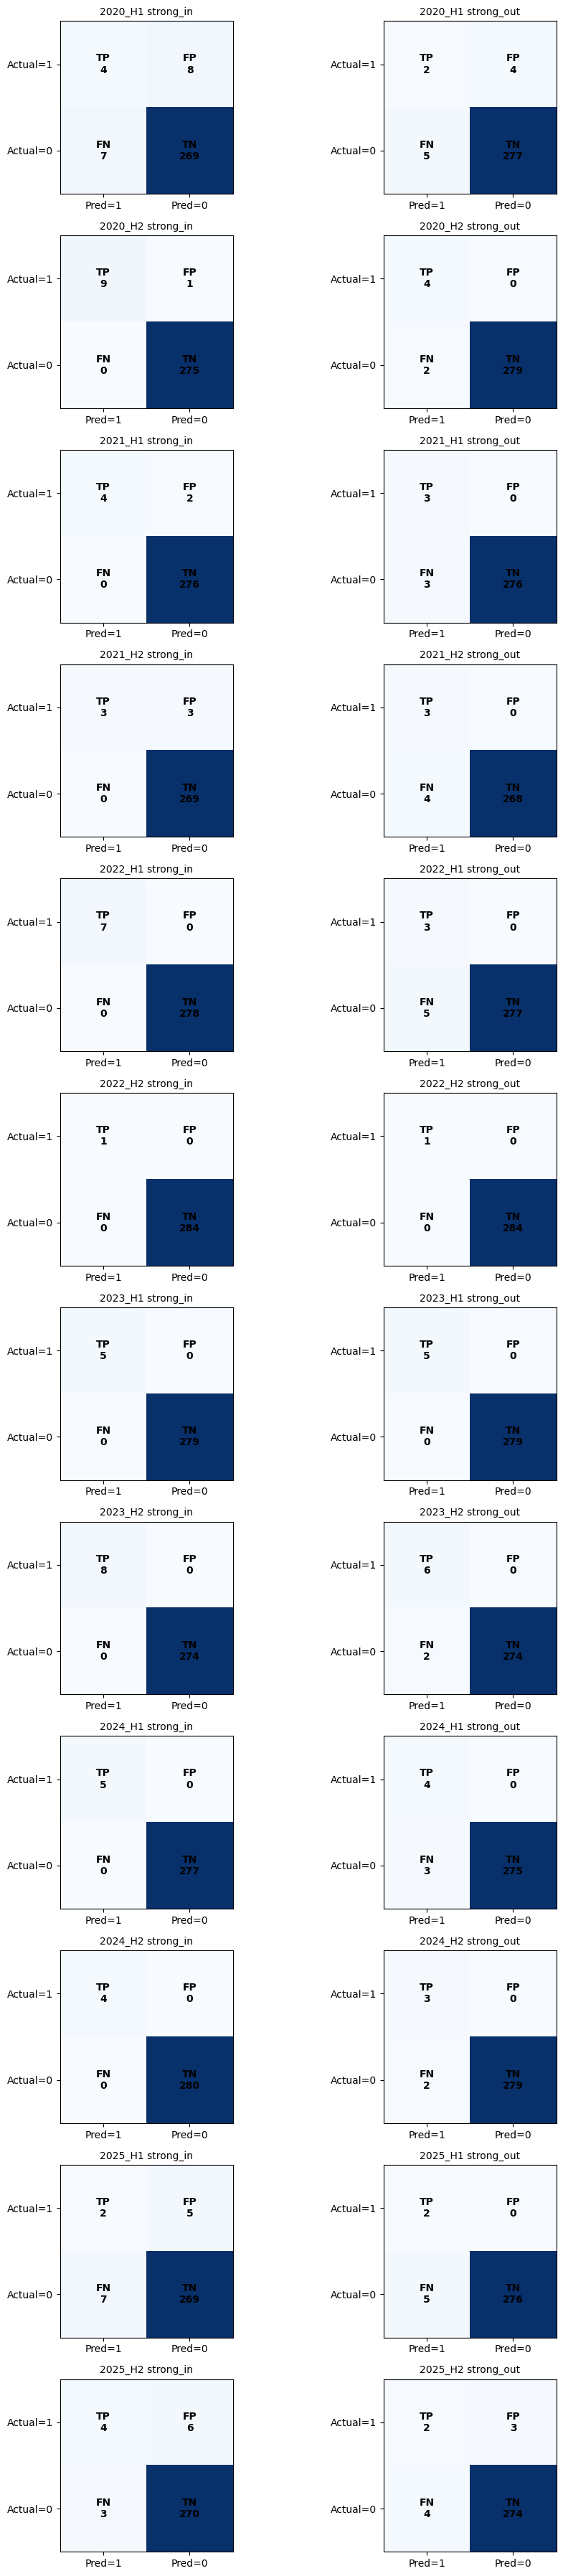

saved: C:\Users\Admin\Desktop\Project\Next200\Next200_v1.5\images\v15_event_confusion_matrix.png


In [43]:
image_path = BASE_DIR / "images" / "v15_event_confusion_matrix.png"
image_path.parent.mkdir(parents=True, exist_ok=True)

periods = strong_in_confusion_df["period"].tolist()
n_periods = len(periods)
fig, axes = plt.subplots(n_periods, 2, figsize=(10, max(3 * n_periods, 8)))

if n_periods == 1:
    axes = np.array([axes])

def draw_confusion_matrix(ax, values, title):
    matrix = np.array([[values["TP"], values["FP"]], [values["FN"], values["TN"]]])
    ax.imshow(matrix, cmap="Blues", vmin=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred=1", "Pred=0"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual=1", "Actual=0"])
    ax.set_title(title, fontsize=10)
    labels = [["TP", "FP"], ["FN", "TN"]]
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{labels[r][c]}\n{int(matrix[r, c])}", ha="center", va="center", fontsize=10, fontweight="bold")

for row_idx, period in enumerate(periods):
    in_values = strong_in_confusion_df.loc[strong_in_confusion_df["period"] == period].iloc[0]
    out_values = strong_out_confusion_df.loc[strong_out_confusion_df["period"] == period].iloc[0]
    draw_confusion_matrix(axes[row_idx, 0], in_values, f"{period} strong_in")
    draw_confusion_matrix(axes[row_idx, 1], out_values, f"{period} strong_out")

plt.tight_layout()
plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"saved: {image_path}")


## 특정 기간 drill-down 예시

아래 표는 한 반기를 선택해서 `hit / predicted_only / missed_actual` 종목명을 직접 확인하는 예시입니다.

In [44]:
target_period = "2024_H1"
target_signal = "strong_out"  # strong_in / strong_out

if "ticker_to_name" in globals() and isinstance(ticker_to_name, dict) and len(ticker_to_name) > 0:
    company_name_map = ticker_to_name
else:
    if "cfg" not in globals():
        from src.config import load_config
        cfg = load_config()
    if "load_table" not in globals():
        from src.sql_dump import load_table
    stock_meta_for_name = load_table(cfg.sql_dump_path, "stock_meta").copy()
    stock_meta_for_name["ticker"] = stock_meta_for_name["ticker"].astype(str).str.zfill(6)
    candidate_name_cols = ["company", "company_name", "name", "corp_name", "stock_name", "issue_name"]
    name_col = next((col for col in candidate_name_cols if col in stock_meta_for_name.columns), None)
    if name_col is None:
        text_cols = [col for col in stock_meta_for_name.columns if col != "ticker" and stock_meta_for_name[col].dtype == "object"]
        if not text_cols:
            raise ValueError(f"회사명으로 쓸 컬럼을 찾지 못했습니다. columns={list(stock_meta_for_name.columns)}")
        name_col = text_cols[0]
    company_name_map = (
        stock_meta_for_name[["ticker", name_col]]
        .dropna()
        .drop_duplicates(subset=["ticker"])
        .set_index("ticker")[name_col]
        .to_dict()
    )

period_detail_df = v15_detail_df.loc[v15_detail_df["period"] == target_period].copy()
period_detail_df["ticker"] = period_detail_df["ticker"].astype(str).str.zfill(6)
period_detail_df["company"] = period_detail_df["ticker"].map(company_name_map).fillna("")

if target_signal == "strong_out":
    pred_col = "strong_out_pred"
    label_col = "label_out"
else:
    pred_col = "strong_in_pred"
    label_col = "label_in"

predicted_set = set(period_detail_df.loc[period_detail_df[pred_col].fillna(0).astype(int) == 1, "ticker"])
actual_set = set(period_detail_df.loc[period_detail_df[label_col].fillna(0).astype(int) == 1, "ticker"])
hit_set = predicted_set & actual_set
predicted_only_set = predicted_set - actual_set
missed_actual_set = actual_set - predicted_set

comparison_rows = []
for ticker in sorted(hit_set):
    comparison_rows.append({"group": "hit", "ticker": ticker, "company": company_name_map.get(ticker, "")})
for ticker in sorted(predicted_only_set):
    comparison_rows.append({"group": "predicted_only", "ticker": ticker, "company": company_name_map.get(ticker, "")})
for ticker in sorted(missed_actual_set):
    comparison_rows.append({"group": "missed_actual", "ticker": ticker, "company": company_name_map.get(ticker, "")})

comparison_detail_df = pd.DataFrame(comparison_rows)
print(f"period={target_period}, signal={target_signal}")
print(
    f"predicted={len(predicted_set)}, actual={len(actual_set)}, "
    f"hit={len(hit_set)}, missed_actual={len(missed_actual_set)}, false_positive={len(predicted_only_set)}"
)
comparison_detail_df


period=2024_H1, signal=strong_out
predicted=4, actual=7, hit=4, missed_actual=3, false_positive=0


,group,ticker,company
0,hit,010780,비금속
1,hit,019170,제약
2,hit,020560,운송·창고
3,hit,031430,유통
4,missed_actual,000990,전기·전자
5,missed_actual,003410,비금속
6,missed_actual,020150,전기·전자


## 36. 지금까지 결과 기준 다음 할 일

현재 노트북 기준으로 다음 액션은 이렇게 정리할 수 있습니다.

1. `v1.5_best = XGBoost + 11개 피처`를 현재 최종 후보로 확정
2. `snapshot_version = v1_5_xgb_11` 같은 이름으로 SQL snapshot 관리 체계 반영
3. 필요하면 `XGBoost 10~12개` 구간의 하이퍼파라미터를 추가 점검
4. rank quality 개선을 위한 다음 단계 설계

## 37. 기간별 상세 예측 리포트

아래 셀은 `v1.5_best = XGBoost + 11개 피처`를 기준으로 `2020_H1 ~ 2025_H2` 각 기간별 상세 결과를 텍스트 리포트 형태로 정리합니다.

- 실제 편입 종목 / 실제 편출 종목
- 강력 편입 예측 TOP10 / 강력 편출 예측 TOP10
- 편입 TOP20 / 편출 TOP20
- precision / recall 요약

In [45]:
def build_company_name_map() -> dict[str, str]:
    candidate_frames = []
    if "stock_meta_hist" in globals() and isinstance(stock_meta_hist, pd.DataFrame):
        candidate_frames.append(stock_meta_hist.copy())
    if "stock_meta" in globals() and isinstance(stock_meta, pd.DataFrame):
        candidate_frames.append(stock_meta.copy())

    name_candidates = ["company", "company_name", "name", "stock_name", "corp_name", "corp_nm"]
    for frame in candidate_frames:
        if "ticker" not in frame.columns:
            continue
        cols = [col for col in name_candidates if col in frame.columns]
        if not cols:
            continue
        name_col = cols[0]
        mapping_frame = frame[["ticker", name_col]].dropna().copy()
        mapping_frame["ticker"] = mapping_frame["ticker"].astype(str).str.zfill(6)
        mapping_frame[name_col] = mapping_frame[name_col].astype(str)
        return dict(zip(mapping_frame["ticker"], mapping_frame[name_col]))
    return {}


def format_report_table(frame: pd.DataFrame, columns: list[str], score_col: str = "score") -> pd.DataFrame:
    display_frame = frame.loc[:, columns].copy()
    if score_col in display_frame.columns:
        display_frame[score_col] = pd.to_numeric(display_frame[score_col], errors="coerce").round(4)
    if "pred_rank" in display_frame.columns:
        display_frame["pred_rank"] = pd.to_numeric(display_frame["pred_rank"], errors="coerce").round(0).astype("Int64")
    if "period_rank" in display_frame.columns:
        display_frame["period_rank"] = pd.to_numeric(display_frame["period_rank"], errors="coerce").round(0).astype("Int64")
    display_frame = display_frame.reset_index(drop=True)
    display_frame.index = display_frame.index + 1
    display_frame.index.name = "rank"
    return display_frame


company_name_map = build_company_name_map()
report_periods = [period for period in full_period_order if period in set(v15_detail_df["period"])]

for target_period in report_periods:
    period_df = v15_detail_df.loc[v15_detail_df["period"] == target_period].copy()
    if period_df.empty:
        continue

    period_df["company"] = period_df["ticker"].map(company_name_map).fillna("")
    period_df["period_rank"] = pd.to_numeric(period_df.get("period_rank"), errors="coerce")
    period_df["prev_was_member"] = pd.to_numeric(period_df.get("prev_was_member"), errors="coerce").fillna(0).astype(int)
    period_df["pred_rank"] = pd.to_numeric(period_df.get("pred_rank"), errors="coerce")
    period_df["score"] = pd.to_numeric(period_df.get("score"), errors="coerce")

    actual_in_set = set(period_df.loc[period_df["label_in"].fillna(0).astype(int) == 1, "ticker"])
    actual_out_set = set(period_df.loc[period_df["label_out"].fillna(0).astype(int) == 1, "ticker"])
    pred_top200 = set(period_df.loc[period_df["pred_rank"] <= 200, "ticker"])
    pred_in_set = set(period_df.loc[period_df["strong_in_pred"].fillna(0).astype(int) == 1, "ticker"])
    pred_out_set = set(period_df.loc[period_df["strong_out_pred"].fillna(0).astype(int) == 1, "ticker"])

    strong_in = (
        period_df.loc[period_df["strong_in_pred"].fillna(0).astype(int) == 1]
        .sort_values(["pred_rank", "score"], ascending=[True, False])
        .copy()
    )
    strong_out = (
        period_df.loc[period_df["strong_out_pred"].fillna(0).astype(int) == 1]
        .sort_values(["pred_rank", "score"], ascending=[True, True])
        .copy()
    )
    in_top20 = (
        period_df.loc[period_df["prev_was_member"] == 0]
        .sort_values(["score", "pred_rank"], ascending=[False, True])
        .head(20)
        .copy()
    )
    out_top20 = (
        period_df.loc[period_df["prev_was_member"] == 1]
        .sort_values(["score", "pred_rank"], ascending=[True, True])
        .head(20)
        .copy()
    )

    print("\n" + "=" * 100)
    print(f"  {target_period} - v1.5 final report (XGBoost + 11 features)")
    print("=" * 100)

    print(f"\nActual inclusions ({len(actual_in_set)}):")
    actual_in_rows = []
    for ticker in sorted(actual_in_set):
        row = period_df.loc[period_df["ticker"] == ticker].head(1)
        period_rank = row["period_rank"].iloc[0] if not row.empty else np.nan
        predicted = "hit" if ticker in pred_in_set else "miss"
        actual_in_rows.append({
            "ticker": ticker,
            "company": company_name_map.get(ticker, ""),
            "mktcap_rank": None if pd.isna(period_rank) else int(period_rank),
            "predicted": predicted,
        })
    display(pd.DataFrame(actual_in_rows) if actual_in_rows else pd.DataFrame(columns=["ticker", "company", "mktcap_rank", "predicted"]))

    print("\nStrong inclusion prediction (TOP10):")
    strong_in_disp = strong_in.head(10).copy()
    strong_in_disp["actual_in"] = strong_in_disp["ticker"].apply(lambda x: "Y" if x in actual_in_set else "")
    display(format_report_table(strong_in_disp, ["ticker", "company", "score", "pred_rank", "period_rank", "actual_in"]))

    print(f"\nActual exclusions ({len(actual_out_set)}):")
    actual_out_rows = []
    for ticker in sorted(actual_out_set):
        row = period_df.loc[period_df["ticker"] == ticker].head(1)
        period_rank = row["period_rank"].iloc[0] if not row.empty else np.nan
        predicted = "hit" if ticker in pred_out_set else "miss"
        actual_out_rows.append({
            "ticker": ticker,
            "company": company_name_map.get(ticker, ""),
            "mktcap_rank": None if pd.isna(period_rank) else int(period_rank),
            "predicted": predicted,
        })
    display(pd.DataFrame(actual_out_rows) if actual_out_rows else pd.DataFrame(columns=["ticker", "company", "mktcap_rank", "predicted"]))

    print("\nStrong exclusion prediction (TOP10):")
    strong_out_disp = strong_out.head(10).copy()
    strong_out_disp["actual_out"] = strong_out_disp["ticker"].apply(lambda x: "Y" if x in actual_out_set else "")
    display(format_report_table(strong_out_disp, ["ticker", "company", "score", "pred_rank", "period_rank", "actual_out"]))

    print("\nInclusion TOP20:")
    in_top20["inside_200"] = in_top20["ticker"].apply(lambda x: "Y" if x in pred_top200 else "")
    in_top20["actual_in"] = in_top20["ticker"].apply(lambda x: "Y" if x in actual_in_set else "")
    display(format_report_table(in_top20, ["ticker", "company", "score", "pred_rank", "period_rank", "inside_200", "actual_in"]))

    print("\nExclusion TOP20:")
    out_top20["outside_200"] = out_top20["ticker"].apply(lambda x: "Y" if x not in pred_top200 else "boundary")
    out_top20["actual_out"] = out_top20["ticker"].apply(lambda x: "Y" if x in actual_out_set else "")
    display(format_report_table(out_top20, ["ticker", "company", "score", "pred_rank", "period_rank", "outside_200", "actual_out"]))

    in_hit = len(pred_in_set & actual_in_set)
    out_hit = len(pred_out_set & actual_out_set)
    in_prec = (in_hit / len(pred_in_set)) if pred_in_set else np.nan
    out_prec = (out_hit / len(pred_out_set)) if pred_out_set else np.nan
    in_recall = (in_hit / len(actual_in_set)) if actual_in_set else np.nan
    out_recall = (out_hit / len(actual_out_set)) if actual_out_set else np.nan

    print("\n" + "-" * 70)
    print(f"Inclusion hit: {in_hit}/{len(pred_in_set)} (Prec={in_prec:.0%})" if pred_in_set else "Inclusion: no prediction")
    if actual_in_set:
        print(f"Actual inclusions {len(actual_in_set)} with {in_hit} hits (Recall={in_recall:.0%})")
    print(f"Exclusion hit: {out_hit}/{len(pred_out_set)} (Prec={out_prec:.0%})" if pred_out_set else "Exclusion: no prediction")
    if actual_out_set:
        print(f"Actual exclusions {len(actual_out_set)} with {out_hit} hits (Recall={out_recall:.0%})")



  2020_H1 - v1.5 final report (XGBoost + 11 features)

Actual inclusions (11):


,ticker,company,mktcap_rank,predicted
0,003670,,76,hit
1,007700,,127,miss
2,009410,,164,miss
3,011200,,152,hit
4,016380,,219,miss
5,020560,,146,hit
6,032350,,179,hit
7,180640,,90,miss
8,192080,,163,miss
9,241590,,173,miss



Strong inclusion prediction (TOP10):


,ticker,company,score,pred_rank,period_rank,actual_in
rank,,,,,,
1,003670,,0.6842,186,76,Y
2,020560,,0.5876,189,146,Y
3,013890,,0.5865,190,139,
4,139130,,0.4526,192,143,
5,012510,,0.3743,193,98,
6,181710,,0.3136,194,135,
7,280360,,0.3092,195,169,
8,011200,,0.2977,196,152,Y
9,000060,,0.2878,197,102,



Actual exclusions (7):


...


Inclusion TOP20:


,ticker,company,score,pred_rank,period_rank,inside_200,actual_in
rank,,,,,,,
1,064400,,0.8230,187,75,Y,Y
2,082740,,0.6989,190,117,Y,Y
3,071970,,0.4965,192,143,Y,
4,007660,,0.3565,194,93,Y,Y
5,003570,,0.2935,195,163,Y,
6,103590,,0.1893,196,164,Y,
7,077970,,0.1851,197,208,Y,
8,294870,,0.1851,198,182,Y,
9,062040,,0.1810,199,119,Y,Y



Exclusion TOP20:


,ticker,company,score,pred_rank,period_rank,outside_200,actual_out
rank,,,,,,,
1,006650,,0.0123,234,284,Y,
2,069260,,0.0212,225,276,Y,
3,145720,,0.0368,218,279,Y,Y
4,005420,,0.0380,215,294,Y,
5,268280,,0.0424,214,268,Y,
6,003620,,0.0432,213,278,Y,Y
7,005250,,0.0873,204,269,Y,
8,008730,,0.4023,193,262,boundary,
9,001680,,0.6177,191,260,boundary,



----------------------------------------------------------------------
Inclusion hit: 4/10 (Prec=40%)
Actual inclusions 7 with 4 hits (Recall=57%)
Exclusion hit: 2/5 (Prec=40%)
Actual exclusions 6 with 2 hits (Recall=33%)
